# Segmentasi RFM: Anggaran Retensi Rp 150 Juta untuk 5.000 Pelanggan

**Analis:** Aulia Aorama · **Tanggal acuan:** 2026-03-31 · **Sumber:** `transactions.csv`, 50.980 baris

**Skenario keputusan:** awal Q2 2026. Data ditarik per 2026-03-31, program berjalan April sampai
Juni 2026, dan hasilnya dibaca pada 2026-06-30. Notebook ini disusun September 2026 sebagai studi
kasus; setiap "sekarang", "kuartal ini", dan "kuartal depan" di bawah merujuk ke skenario itu,
bukan ke tanggal penyusunannya.

Notebook ini menjalankan seluruh rantai analisis, dari tabel mentah sampai tiga gambar
yang masuk portofolio. Pembagian kerjanya disengaja:

| Alat | Tugas |
|---|---|
| SQL (DuckDB) | pembersihan, agregasi, dan **seluruh angka** |
| Python | hanya merender gambar |

Tidak ada satu angka pun yang dihitung di Python. Setiap nilai yang muncul di gambar
datang dari kueri di notebook ini, dan pipeline-nya identik dengan versi ClickHouse di
catatan keputusan. Yang berbeda cuma sintaks fungsi tanggal dan kuantil; angkanya wajib
sama, dan itu diperiksa oleh gerbang di Bagian 2.

**Catatan data:** angka-angka di bawah dihitung dari dataset yang dirancang meniru pola
transaksi marketplace. Ini bukan data sebuah perusahaan sungguhan.

---

## Persoalannya

Sebuah marketplace menengah dengan lima kategori produk memegang anggaran retensi
Rp 150 juta per kuartal untuk 5.000 pelanggan aktif. Dibagi rata, angka itu berarti
**Rp 30.000 per pelanggan per kuartal**.
Kuartal sebelumnya promosi dikirim ke semua orang dan menghasilkan open rate 12% serta
redemption voucher 3%.

Pertanyaan yang harus dijawab: pelanggan mana yang mendapat porsi terbesar, mana yang
cukup dijaga dengan usaha minimal, dan mana yang sudah terlalu jauh untuk dikejar.
Pembagiannya harus bisa dipertahankan di hadapan pemegang anggaran, angka demi angka.

**Angka konteks di atas (Rp 150 juta, 12%, 3%) berasal dari laporan pemangku
kepentingan, bukan dari tabel transaksi.** Ketiganya dikutip sebagai konteks dan tidak
menopang satu pun temuan di notebook ini.

---

## Tiga keputusan yang ditetapkan sebelum kueri pertama ditulis

Segmentasi RFM bisa ditulis dalam dua puluh baris, dan kueri itu akan berjalan mulus
tanpa satu pesan galat pun. Masalahnya, kueri yang ditulis tanpa tiga keputusan berikut
tetap **mengambil** ketiganya, hanya saja diam-diam, dengan jawaban bawaan yang hampir
selalu bukan yang diinginkan.

| # | Keputusan | Yang dipilih | Yang ditolak |
|---|---|---|---|
| 1 | Transaksi mana yang layak dihitung | Baris unik lima kolom, bernilai positif, sampai tanggal acuan | Memakai semua baris apa adanya |
| 2 | "Sekarang" itu kapan | `2026-03-31` literal, tanggal terakhir data bersih | `today()`, hasilnya berubah tiap hari |
| 3 | Di mana garis antar-segmen ditarik | Ambang ditetapkan sesudah membaca sebaran, lalu diuji kepekaannya | Meminjam ambang tanpa memeriksa sebaran |

Rincian lengkap berikut alasan tiap penolakan ada di catatan keputusan.


## 1. Persiapan

In [1]:
import duckdb
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch, Rectangle

CSV   = "transactions.csv"
ACUAN   = "2026-03-31"    # literal, bukan today()
JENDELA = 15              # bulan; riwayat F dan M dihitung dalam jendela tetap ini

# Palet sendiri. Biru petrol sebagai warna utama, amber sebagai penanda
# perhatian. Pasangan biru-oranye terbaca oleh pembaca dengan buta warna
# merah-hijau, tidak seperti pasangan merah-abu.
PETROL, PETROL_MUDA = "#1F5673", "#7FA8BF"
AMBER               = "#D97A34"
SLATE_MUDA          = "#CDD2D6"
TEKS, TEKS_LEMBUT   = "#16212B", "#5C6670"
GARIS               = "#E3E7EA"
URUTAN            = ["Champions", "Loyal", "At Risk", "Lost"]

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.edgecolor": GARIS, "axes.labelcolor": TEKS_LEMBUT,
    "text.color": TEKS, "xtick.color": TEKS_LEMBUT, "ytick.color": TEKS_LEMBUT,
    "figure.dpi": 130, "savefig.dpi": 160,
    "savefig.bbox": "tight", "savefig.facecolor": "white",
})

con = duckdb.connect()
def q(sql):
    """Jalankan SQL, kembalikan DataFrame."""
    return con.execute(sql).df()

con.execute(f"""
CREATE OR REPLACE TABLE transactions AS
SELECT * FROM read_csv('{CSV}', header = true,
  columns = {{
    'TransactionID'  : 'VARCHAR',
    'CustomerID'     : 'VARCHAR',
    'TransactionDate': 'DATE',
    'TotalValue'     : 'DOUBLE',
    'ProductCategory': 'VARCHAR'
  }});
""")
# Tiruan quantileExact ClickHouse: elemen ke-floor(n*p)+1 dari data terurut.
# Untuk n genap dan p=0,5 ia mengambil nilai tengah ATAS, berbeda dari
# quantile_cont (interpolasi) maupun quantile_disc (nilai bawah) milik DuckDB.
con.execute("CREATE OR REPLACE MACRO q_exact(x, p) AS "
            "list_sort(list(x))[CAST(floor(count(x) * p) AS BIGINT) + 1]")
print("Tabel mentah dimuat.")

Tabel mentah dimuat.


## 2. Profil dulu, bersihkan kemudian

Urutan ini menyelamatkan berkali-kali: **profil dulu, putuskan kemudian, bersihkan
terakhir.** Filter yang ditulis sebelum data diprofilkan adalah tebakan, karena Anda
belum tahu kotoran mana yang tidak Anda duga sehingga tidak Anda saring.

Profil juga memberi **angka sebelum**. Pipeline yang dibangun tanpa profil hanya tahu
angka sesudahnya, dan tidak bisa menjawab pertanyaan pemeriksa yang paling sederhana:
memangnya tadinya berapa, dan ke mana selisihnya.

In [2]:
q("""
SELECT
    count(*)                                                 AS baris,
    count(DISTINCT CustomerID)                               AS pelanggan,
    min(TransactionDate)                                     AS tanggal_awal,
    max(TransactionDate)                                     AS tanggal_akhir,
    count(*) FILTER (WHERE TransactionID   IS NULL)          AS id_kosong,
    count(*) FILTER (WHERE CustomerID      IS NULL)          AS pelanggan_kosong,
    count(*) FILTER (WHERE TransactionDate IS NULL)          AS tanggal_kosong,
    count(*) FILTER (WHERE ProductCategory IS NULL)          AS kategori_kosong,
    count(*) FILTER (WHERE TotalValue      IS NULL)          AS nilai_kosong,
    min(TotalValue)                                          AS nilai_terendah,
    count(*) FILTER (WHERE TotalValue <= 0)                  AS tak_positif
FROM transactions
""")

,baris,pelanggan,tanggal_awal,tanggal_akhir,id_kosong,pelanggan_kosong,tanggal_kosong,kategori_kosong,nilai_kosong,nilai_terendah,tak_positif
0,50980,5000,2025-01-01,2026-12-24,0,0,0,0,350,-690111.44,50


Cara membaca tabel profil bukan "mencari yang aneh", karena itu terlalu bergantung
keberuntungan. Caranya: tulis dulu harapan Anda sebelum kuerinya jalan, lalu bandingkan.
Harapan dari brief kasus: sekitar lima puluh ribu baris, sekitar lima ribu pelanggan,
rentang awal 2025 sampai kuartal pertama 2026.

Tiga dari empat angka memenuhi harapan. Yang keempat menabraknya: **tanggal terakhir
2026-12-24**, sembilan bulan miring ke masa depan, padahal analisisnya per 2026-03-31.
Kueri berumur lima detik baru saja menemukan hal yang akan merusak seluruh perhitungan
Recency, dan menemukannya sebelum perhitungan itu ditulis.

Dua hal lain yang layak dicatat, dan keduanya **temuan**, bukan formalitas:

- NULL hanya ada di `TotalValue`. Empat kolom lain nol kosong seluruhnya. Ini yang
  membuat pipeline di bawah **tidak** memasang pagar `CustomerID IS NOT NULL`.
  Memasangnya boleh, tetapi hari ini ia membuang nol baris, dan menulis "data
  dibersihkan dari ID kosong" padahal tidak ada satu pun ID kosong adalah mengarang
  pekerjaan.
- Nilai terendah negatif, yang di tabel transaksi hampir selalu berarti refund.

### Empat kotoran, dihitung satu per satu

Sebelum membuang apa pun, hitung dulu berapa banyak masing-masing. Angka-angka inilah
yang nanti dicocokkan dengan gerbang penerimaan.

In [3]:
q(f"""
WITH deduped AS (
    SELECT DISTINCT TransactionID, CustomerID, TransactionDate, TotalValue, ProductCategory
    FROM transactions
)
SELECT
    (SELECT count(*) FROM transactions) - (SELECT count(*) FROM deduped)  AS duplikat_persis,
    (SELECT count(*) FROM deduped WHERE TotalValue IS NULL)               AS gagal_bayar_null,
    (SELECT count(*) FROM deduped WHERE TotalValue <= 0)                  AS nol_atau_negatif,
    (SELECT count(*) FROM deduped WHERE TransactionDate > DATE '{ACUAN}') AS melewati_acuan
""")

,duplikat_persis,gagal_bayar_null,nol_atau_negatif,melewati_acuan
0,2400,350,50,50


**Kenapa masing-masing dibuang, dan kenapa keputusannya harus eksplisit.**

*Duplikat persis.* Baris-baris ini identik **termasuk `TransactionID`**, yang seharusnya
unik. Dua pembelian sungguhan, bahkan barang sama pada hari sama dengan nilai sama,
tercatat dengan dua nomor transaksi berbeda; itulah fungsi nomor transaksi. Baris dengan
nomor yang sama bukan dua kejadian melainkan satu kejadian yang tercatat dua kali.

*Pembayaran gagal.* RFM mengukur perilaku belanja, dan pembayaran yang gagal bukan
belanja. Keputusan ini **harus** eksplisit, karena kalau dibiarkan, `sum()` melewati NULL
sementara `count()` tetap menghitungnya. Hasilnya: Frequency memakai definisi longgar dan
Monetary memakai definisi ketat, di kueri yang sama, tanpa satu pun tanda peringatan.

*Nol dan negatif.* Refund dan sampel gratis. Keduanya kejadian nyata, keduanya bukan
perilaku belanja yang sedang diukur. Perhatikan bahwa arah keputusan ini bisa berbalik di
analisis lain: analisis kepuasan pelanggan justru akan **mempertahankan** refund sebagai
sinyal. Yang menentukan bukan sifat datanya, melainkan pertanyaan yang sedang dijawab.

*Melewati tanggal acuan.* Ini yang paling dramatis kalau dibiarkan. `dateDiff` akan
menghasilkan Recency **negatif**, dan Recency negatif lolos syarat "kurang dari atau sama
dengan 30 hari" dengan sempurna. Pelanggan dengan data paling rusak akan tampil sebagai
pelanggan paling segar di seluruh tabel.

### Pipeline bertahap, satu tahap satu kotoran

Bentuknya rangkaian CTE, satu CTE satu tahap, dengan urutan yang disengaja. Dedup
berjalan **pertama** supaya baris NULL yang dibuang tahap dua benar-benar transaksi gagal
bayar, bukan campuran transaksi dan salinannya. Membalik urutannya tetap berujung 48.130,
tetapi angka antara di tiap tahap berubah makna, dan angka antara itulah yang dikutip
saat menjelaskan pekerjaan ini ke orang lain.

Bandingkan dengan bentuk yang digantikannya: satu `WHERE` panjang yang membuang 2.850
baris sekaligus tanpa bisa menjelaskan siapa membuang apa. Kedua bentuk menghasilkan
48.130 yang sama persis; hanya satu yang bisa diaudit.

In [4]:
con.execute(f"""
CREATE OR REPLACE TABLE deduped AS
SELECT DISTINCT TransactionID, CustomerID, TransactionDate, TotalValue, ProductCategory
FROM transactions;

CREATE OR REPLACE TABLE null_filtered AS
SELECT * FROM deduped        WHERE TotalValue IS NOT NULL;

CREATE OR REPLACE TABLE positive_filtered AS
SELECT * FROM null_filtered  WHERE TotalValue > 0;

CREATE OR REPLACE TABLE cleaned_data AS
SELECT * FROM positive_filtered WHERE TransactionDate <= DATE '{ACUAN}';
""")

q("""
SELECT * FROM (VALUES
    ('--',                  'mentah',             NULL, (SELECT count(*) FROM transactions)),
    ('deduped',             'duplikat persis',    (SELECT count(*) FROM transactions)      - (SELECT count(*) FROM deduped),           (SELECT count(*) FROM deduped)),
    ('null_filtered',       'TotalValue NULL',    (SELECT count(*) FROM deduped)           - (SELECT count(*) FROM null_filtered),     (SELECT count(*) FROM null_filtered)),
    ('positive_filtered',   'TotalValue <= 0',    (SELECT count(*) FROM null_filtered)     - (SELECT count(*) FROM positive_filtered), (SELECT count(*) FROM positive_filtered)),
    ('cleaned_data',        'tanggal > acuan',    (SELECT count(*) FROM positive_filtered) - (SELECT count(*) FROM cleaned_data),      (SELECT count(*) FROM cleaned_data))
) AS t(tahap, membuang, dibuang, sisa)
""")

,tahap,membuang,dibuang,sisa
0,--,mentah,<NA>,50980
1,deduped,duplikat persis,2400,48580
2,null_filtered,TotalValue NULL,350,48230
3,positive_filtered,TotalValue <= 0,50,48180
4,cleaned_data,tanggal > acuan,50,48130


### Gerbang penerimaan

Tujuh angka yang harus keluar persis. Aturan pakainya satu, dan melanggarnya membuang
waktu yang justru ingin dihemat: **kalau angka Anda berbeda, yang diburu definisinya,
bukan bug-nya.** Hampir semua selisih di gerbang ini bukan salah ketik melainkan salah
definisi, misalnya dedup yang memakai `TransactionID` saja alih-alih kelima kolom, filter
`<` alih-alih `<=`, atau tanggal acuan yang meleset sehari.

In [5]:
g = q("""
SELECT
    (SELECT count(*) FROM transactions)                 AS mentah,
    (SELECT count(*) FROM deduped)                      AS setelah_dedup,
    (SELECT count(*) FROM null_filtered)                AS setelah_null,
    (SELECT count(*) FROM positive_filtered)            AS setelah_positif,
    (SELECT count(*) FROM cleaned_data)                 AS bersih,
    (SELECT count(DISTINCT CustomerID) FROM transactions)  AS pelanggan_mentah,
    (SELECT count(DISTINCT CustomerID) FROM cleaned_data)  AS pelanggan_bersih
""")

harapan = dict(mentah=50980, setelah_dedup=48580, setelah_null=48230,
               setelah_positif=48180, bersih=48130,
               pelanggan_mentah=5000, pelanggan_bersih=5000)

for kolom, nilai_harapan in harapan.items():
    nilai = int(g[kolom][0])
    tanda = "cocok" if nilai == nilai_harapan else f"MELESET (harusnya {nilai_harapan:,})"
    print(f"  {kolom:<18} {nilai:>7,}   {tanda}")

assert all(int(g[k][0]) == v for k, v in harapan.items()), \
    "Gerbang tidak cocok. Buru definisinya dulu, bukan bug-nya."
print("\nGerbang lolos. Pembersihan membuang 2.850 baris (5,6% dari mentah).")

  mentah              50,980   cocok
  setelah_dedup       48,580   cocok
  setelah_null        48,230   cocok
  setelah_positif     48,180   cocok
  bersih              48,130   cocok
  pelanggan_mentah     5,000   cocok
  pelanggan_bersih     5,000   cocok

Gerbang lolos. Pembersihan membuang 2.850 baris (5,6% dari mentah).


Dua hal yang **boleh** diklaim dari pembersihan ini: data kini konsisten dengan definisi
yang dinyatakan, dan setiap baris yang dibuang bisa dipertanggungjawabkan jenis serta
jumlahnya.

Satu hal yang **tidak boleh** diklaim: bahwa datanya kini "benar". Pembersihan tidak
memverifikasi bahwa transaksi yang tersisa sungguh terjadi, tidak menemukan transaksi
yang gagal tercatat, dan tidak tahu apa pun tentang pelanggan yang berbelanja di tempat
lain. Ia menegakkan definisi; ia tidak memperbaiki dunia.

Perhatikan juga jumlah pelanggan unik: **tetap 5.000 di data mentah maupun bersih**.
Artinya 2.850 baris yang dibuang milik pelanggan yang masih punya transaksi sah lainnya.
Ini kebetulan yang menyenangkan di dataset ini, **bukan jaminan alam**. Di data lain,
membuang baris bisa ikut menghilangkan pelanggan, dan perubahan jumlah pelanggan antara
mentah dan bersih adalah angka yang wajib diperiksa setiap kali.

## 3. Sebaran sebelum garis ditarik

Ini seksi yang paling sering dilewati, dan melewatinya punya harga yang baru terasa
belakangan. Analis yang melompat langsung ke ambang tetap bisa menjalankan segmentasi,
tetapi ketika ditanya "kenapa garisnya di situ?", satu-satunya jawaban yang tersedia
adalah "kebiasaan industri".

Lima angka ringkas per ukuran sudah cukup untuk melihat bentuk populasi tanpa menggambar
satu grafik pun.

**Jendela riwayat tetap 15 bulan.** Frequency dan Monetary dihitung hanya dari transaksi dalam
15 bulan sampai tanggal acuan, bukan dari seluruh riwayat. Per 2026-03-31 jendela itu persis
seluruh data bersih (2025-01-01 sampai 2026-03-31), jadi tidak ada satu angka pun yang berubah
hari ini. Gunanya baru terasa saat segmentasi dijalankan ulang tiap kuartal: tanpa jendela tetap,
setiap kuartal menambah tiga bulan akumulasi, ambang F dan M yang absolut makin mudah dilewati,
dan perbandingan antar-kuartal mencampur perubahan perilaku dengan perubahan panjang riwayat.
Per 2026-06-30 jendelanya bergeser menjadi 2025-04-01 sampai 2026-06-30.

In [6]:
con.execute(f"""
CREATE OR REPLACE TABLE rfm_scores AS
SELECT
    CustomerID,
    (DATE '{ACUAN}' - max(TransactionDate)) AS Recency,
    count(*)                                AS Frequency,
    sum(TotalValue)                         AS Monetary
FROM cleaned_data
WHERE TransactionDate >= CAST(DATE '{ACUAN}' + 1 - INTERVAL {JENDELA} MONTH AS DATE)
GROUP BY CustomerID;
""")

# Jendela per 2026-03-31 harus mencakup seluruh 48.130 transaksi bersih.
cek = q(f"""SELECT CAST(DATE '{ACUAN}' + 1 - INTERVAL {JENDELA} MONTH AS DATE) AS awal_jendela,
       (SELECT sum(Frequency) FROM rfm_scores) AS transaksi_dalam_jendela,
       (SELECT count(*) FROM rfm_scores)       AS pelanggan""")
display(cek)
assert int(cek.transaksi_dalam_jendela[0]) == 48130 and int(cek.pelanggan[0]) == 5000

# Kuartil memakai tiruan quantileExact supaya sama persis dengan ClickHouse.
q("""
SELECT 'Recency (hari)' AS ukuran, min(Recency) AS min,
       q_exact(Recency,0.25) AS q1, q_exact(Recency,0.5) AS median,
       q_exact(Recency,0.75) AS q3, max(Recency) AS maks
FROM rfm_scores
UNION ALL
SELECT 'Frequency (transaksi)', min(Frequency),
       q_exact(Frequency,0.25), q_exact(Frequency,0.5),
       q_exact(Frequency,0.75), max(Frequency)
FROM rfm_scores
UNION ALL
SELECT 'Monetary (Rp)', round(min(Monetary)),
       round(q_exact(Monetary,0.25)), round(q_exact(Monetary,0.5)),
       round(q_exact(Monetary,0.75)), round(max(Monetary))
FROM rfm_scores
""")

,awal_jendela,transaksi_dalam_jendela,pelanggan
0,2025-01-01,48130.0,5000


,ukuran,min,q1,median,q3,maks
0,Recency (hari),0.0,17.0,61.0,126.0,440.0
1,Frequency (transaksi),2.0,4.0,7.0,14.0,25.0
2,Monetary (Rp),44457.0,650185.0,1358137.0,3121396.0,10878758.0


Tabel kecil ini adalah **peta yang menjaga setiap garis dari kesewenang-wenangan.**
Bacaannya:

- Separuh pelanggan terakhir belanja dalam 61 hari; seperempatnya sudah menghilang lebih
  dari 126 hari. Rentang yang lebar dan sehat untuk segmentasi, karena garis di mana pun
  akan membelah kelompok yang sungguh berbeda.
- Frequency membentang 2 sampai 25 dengan median 7. Ambang `>= 8` yang sebentar lagi
  dipakai untuk Loyal membelah **tepat di atas median**, membagi populasi hampir dua sama
  besar. Ini garis yang paling menanggung beban, dan Bagian 7 mengukur bebannya.
- Monetary median sekitar Rp 1,36 juta dengan puncak Rp 10,88 juta. Ambang Rp 5 juta
  untuk Champions berdiri **jauh di atas kuartil ketiga**, yang berarti segmen puncaknya
  memang dirancang sempit. Kesempitan itu disengaja, bukan kebetulan.

Tiga kalimat di atas adalah **pembelaan ambang sebelum ambangnya dipakai**. Itu bedanya
dengan menjawab "kebiasaan industri" enam bulan kemudian, saat jejaknya sudah dingin.

## 4. Segmentasi

Empat segmen, tiga garis. Sebelum menjadi kode, ketiganya dinyatakan terbuka dalam bahasa
manusia, karena tabel inilah yang kelak dibaca pemegang anggaran, bukan kuerinya.

| Segmen | Syarat | Maknanya dalam perilaku |
|---|---|---|
| Champions | R ≤ 30 **dan** F ≥ 15 **dan** M > Rp 5 jt | Masih hangat, sangat sering, bernilai besar. Tiga syarat sekaligus, sengaja sempit |
| Loyal | R ≤ 90 **dan** F ≥ 8 | Masih dalam kebiasaan belanja kuartalan, frekuensi di atas median |
| At Risk | R > 90 **dan** F ≥ 5 | Dulu rajin, terbukti dari frekuensinya, tetapi sudah satu kuartal lebih menghilang |
| Lost | sisanya | Jarang dan lama tak terlihat, atau baru dan belum terbentuk kebiasaannya |

**Urutan cabang adalah logika, bukan gaya.** `CASE` berhenti di syarat pertama yang
terpenuhi, dan setiap Champions juga memenuhi syarat Loyal, karena R ≤ 30 berarti R ≤ 90
dan F ≥ 15 berarti F ≥ 8. Mereka tertangkap cabang pertama sebelum cabang kedua sempat
bertanya.

Buktikan pada diri sendiri dengan membaliknya di kepala: taruh cabang Loyal lebih dulu,
dan keempat ratus Champions akan tertangkap di sana. Hasilnya Champions kosong dan Loyal
menampung 1.500 orang, **tanpa satu pesan galat pun.** Kueri yang urutan cabangnya keliru
adalah anggota keluarga yang sudah kita kenal: kueri salah yang berjalan mulus.

In [7]:
con.execute("""
CREATE OR REPLACE TABLE rfm_segmented AS
SELECT *,
    CASE
        WHEN Recency <= 30 AND Frequency >= 15 AND Monetary > 5000000 THEN 'Champions'
        WHEN Recency <= 90 AND Frequency >= 8                          THEN 'Loyal'
        WHEN Recency >  90 AND Frequency >= 5                          THEN 'At Risk'
        ELSE 'Lost'
    END AS Segment
FROM rfm_scores;
""")

# CATATAN METODE KUANTIL, penting untuk konsistensi lintas berkas.
# quantile_cont DuckDB menginterpolasi dan quantile_disc mengambil nilai bawah;
# keduanya TIDAK sama dengan quantileExact ClickHouse, yang untuk jumlah genap
# mengembalikan elemen di posisi floor(n/2)+1. Segmen Lost berjumlah genap 2.600
# dengan dua nilai tengah 90/91 dan 4/5, sehingga ketiga metode berbeda jawaban.
# Angka resmi seluruh berkas berasal dari ClickHouse, jadi di sini quantileExact
# ditiru eksplisit.
profil_segmen = q("""
WITH berperingkat AS (
    SELECT Segment, Recency, Frequency, Monetary,
           row_number() OVER (PARTITION BY Segment ORDER BY Recency)   AS rn_r,
           row_number() OVER (PARTITION BY Segment ORDER BY Frequency) AS rn_f,
           row_number() OVER (PARTITION BY Segment ORDER BY Monetary)  AS rn_m,
           count(*)     OVER (PARTITION BY Segment)                    AS n
    FROM rfm_segmented
)
SELECT
    Segment,
    max(n)                                                        AS pelanggan,
    round(max(n) * 100.0 / sum(max(n)) OVER (), 1)                AS pangsa_pelanggan,
    max(CASE WHEN rn_r = floor(n/2)+1 THEN Recency   END)         AS median_R,
    max(CASE WHEN rn_f = floor(n/2)+1 THEN Frequency END)         AS median_F,
    round(max(CASE WHEN rn_m = floor(n/2)+1 THEN Monetary END))   AS median_M,
    round(sum(Monetary))                                          AS total_nilai,
    round(sum(Monetary) * 100.0 / sum(sum(Monetary)) OVER (), 1)  AS pangsa_nilai
FROM berperingkat
GROUP BY Segment
ORDER BY pelanggan DESC
""")
profil_segmen

,Segment,pelanggan,pangsa_pelanggan,median_R,median_F,median_M,total_nilai,pangsa_nilai
0,Lost,2600,52.0,91,5,669674.0,1.822238e+09,16.4
1,Loyal,1100,22.0,19,16,3027313.0,3.353539e+09,30.2
2,At Risk,900,18.0,112,11,3006102.0,2.741303e+09,24.7
3,Champions,400,8.0,3,22,8057608.0,3.183642e+09,28.7


Kolom median inilah yang membuat tiap segmen bisa **diceritakan**, dan tanpa cerita itu
rekomendasi anggaran tidak punya alasan.

- **Champions** terakhir belanja tiga hari lalu, 22 transaksi, sekitar Rp 8 juta per
  orang. Ini pelanggan yang hidup di aplikasi.
- **At Risk** median 11 transaksi membuktikan mereka dulu rajin; median 112 hari
  membuktikan mereka sudah pergi satu kuartal. Kombinasi itulah yang membuat segmen ini
  layak dikejar.
- **Lost** median frekuensinya hanya 5 dan median nilainya sekitar Rp 0,67 juta. Artinya
  sebagian besar Lost **bukan pelanggan setia yang hilang**, melainkan pembeli ringan yang
  tidak pernah terbentuk kebiasaannya. Nuansa ini mengubah nada rekomendasi tentang
  mereka. Komposisinya diperiksa di sel berikut, karena label "Lost" menyimpan satu jebakan.

Satu pola layak dicurigai sebelum dikagumi, karena pemeriksa yang baik selalu menguji
hasil yang terlalu rapi: kenapa median Frequency Loyal (16) lebih tinggi daripada At Risk
(11)? Masuk akal, karena keduanya dulu sama rajin dan At Risk berhenti lebih awal
sehingga hitungannya berhenti tumbuh. Bukan tanda kebocoran cabang.

In [8]:
q("""
SELECT CASE WHEN Recency <= 30 THEN 'a. aktif 0 sampai 30 hari'
            WHEN Recency <= 90 THEN 'b. aktif 31 sampai 90 hari'
            ELSE                    'c. lebih dari 90 hari' END AS sejak_transaksi_terakhir,
       count(*)              AS pelanggan,
       min(Frequency)        AS F_min,
       max(Frequency)        AS F_maks,
       round(sum(Monetary))  AS nilai
FROM rfm_segmented WHERE Segment = 'Lost'
GROUP BY 1 ORDER BY 1
""")

,sejak_transaksi_terakhir,pelanggan,F_min,F_maks,nilai
0,a. aktif 0 sampai 30 hari,606,5,7,570558646.0
1,b. aktif 31 sampai 90 hari,694,5,7,646662843.0
2,c. lebih dari 90 hari,1300,2,4,605016757.0


Segmen Lost terbelah dua sama besar. **1.300 orang masih bertransaksi dalam 90 hari terakhir**,
606 di antaranya dalam 30 hari terakhir, tetapi hanya 5 sampai 7 kali dalam 15 bulan, sehingga tidak
lolos syarat F ≥ 8 untuk Loyal. **1.300 lainnya sudah lebih dari 90 hari tak terlihat** dengan 2
sampai 4 transaksi, sehingga juga tidak lolos syarat F ≥ 5 untuk At Risk.

Keduanya pembeli ringan, jadi kesimpulan "kebiasaan tidak pernah terbentuk" tetap berdiri. Yang
tidak berdiri adalah gambaran bahwa seluruh Lost "sudah lama pergi": separuhnya masih belanja.
Label segmen dipertahankan supaya konsisten dengan ketiga berkas lain, tetapi setiap kalimat tentang
Lost di bawah menyebut komposisi ini, dan kandidat untuk iterasi berikutnya adalah memecahnya
menjadi dua segmen dengan nama yang jujur.

### Aritmetika silang

Lima belas detik, dan kegagalan salah satunya adalah alarm paling dini yang bisa dipunya.
Cabang yang bertumpang tindih atau bocor tertangkap di sini, sebelum sempat sampai ke
slide.

In [9]:
silang = q("""
SELECT
    sum(pelanggan)          AS jumlah_segmen,
    count(DISTINCT Segment) AS banyak_segmen,
    round(sum(pangsa_pelanggan), 1) AS total_pangsa_pelanggan,
    round(sum(pangsa_nilai), 1)     AS total_pangsa_nilai,
    (SELECT count(*) FROM rfm_segmented WHERE Segment IS NULL) AS segmen_kosong
FROM (
    SELECT Segment, count(*) pelanggan,
           count(*) * 100.0 / sum(count(*)) OVER ()          AS pangsa_pelanggan,
           sum(Monetary) * 100.0 / sum(sum(Monetary)) OVER () AS pangsa_nilai
    FROM rfm_segmented GROUP BY Segment
)
""")
display(silang)

assert int(silang.jumlah_segmen[0]) == 5000,      "Jumlah segmen tidak 5.000"
assert float(silang.total_pangsa_pelanggan[0]) == 100.0, "Pangsa pelanggan tidak 100%"
assert float(silang.total_pangsa_nilai[0]) == 100.0,     "Pangsa nilai tidak 100%"
assert int(silang.segmen_kosong[0]) == 0,         "Ada segmen kosong"
print("Aritmetika silang jalan.")

,jumlah_segmen,banyak_segmen,total_pangsa_pelanggan,total_pangsa_nilai,segmen_kosong
0,5000.0,4,100.0,100.0,0


Aritmetika silang jalan.


## 5. Tiga gambar

Aturannya satu gambar satu temuan, dan satu temuan satu gambar. Disiplin itu juga
memangkas kandidat: tabel sebaran kuartil yang indah di Bagian 3 **tidak** masuk, karena
ia menopang keputusan ambang, bukan temuan. Tangkapan layar hasil kueri juga tidak masuk,
karena ia bukti kueri jalan, bukan bukti temuan benar.

Uji untuk gambar keempat kalau tergoda menambah: *temuan mana yang berhenti bisa
dipercaya kalau gambar ini dihapus?* Kalau tidak ada, gambar itu hiasan, dan di dokumen
satu halaman hiasan membayar sewanya dengan perhatian pembaca yang justru paling mahal.

Seluruh angka di ketiga gambar diambil dari kueri; Python hanya merender.

### Gambar 1: siapa yang porsinya lebih besar dari jumlahnya

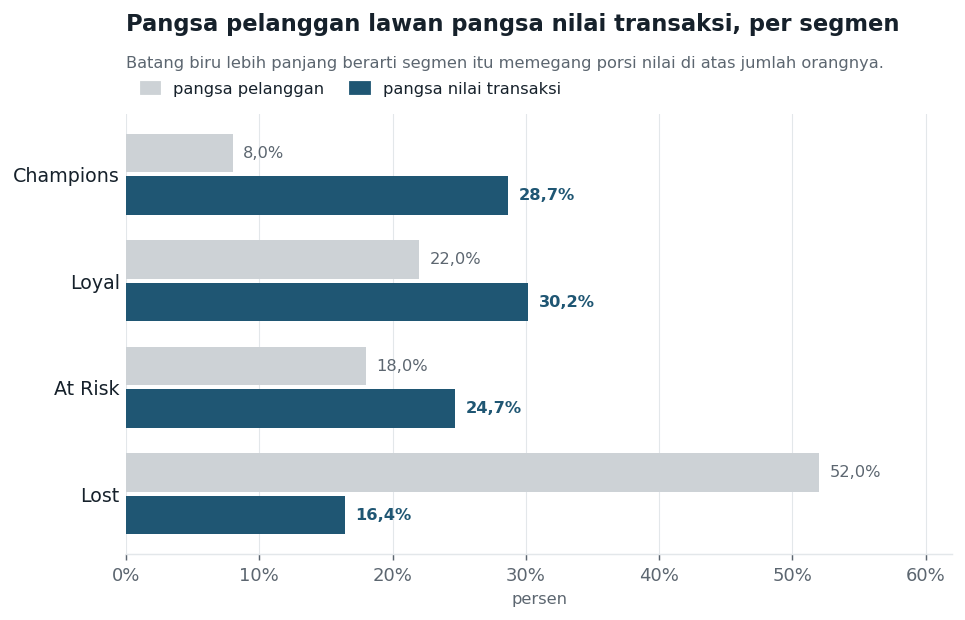

In [10]:
d = q("""
SELECT Segment,
       round(count(*) * 100.0 / sum(count(*)) OVER (), 1)           AS pangsa_pelanggan,
       round(sum(Monetary) * 100.0 / sum(sum(Monetary)) OVER (), 1) AS pangsa_nilai
FROM rfm_segmented GROUP BY Segment
""").set_index("Segment")

fig, ax = plt.subplots(figsize=(8.2, 4.4))
tinggi = 0.36
for i, s in enumerate(URUTAN):
    pel, nil = d.loc[s, "pangsa_pelanggan"], d.loc[s, "pangsa_nilai"]
    ax.barh(i - tinggi/2 - 0.02, pel, height=tinggi, color=SLATE_MUDA, zorder=3)
    ax.barh(i + tinggi/2 + 0.02, nil, height=tinggi, color=PETROL, zorder=3)
    ax.text(pel + 0.8, i - tinggi/2 - 0.02, f"{pel:.1f}%".replace(".", ","),
            va="center", fontsize=9, color=TEKS_LEMBUT)
    ax.text(nil + 0.8, i + tinggi/2 + 0.02, f"{nil:.1f}%".replace(".", ","),
            va="center", fontsize=9, color=PETROL, fontweight="bold")

ax.set_yticks(range(len(URUTAN))); ax.set_yticklabels(URUTAN, fontsize=10.5, color=TEKS)
ax.invert_yaxis(); ax.set_xlim(0, 62); ax.set_xlabel("persen", fontsize=9)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Pangsa pelanggan lawan pangsa nilai transaksi, per segmen",
             fontsize=12.5, fontweight="bold", pad=46, loc="left", color=TEKS)
ax.text(0, 1.105, "Batang biru lebih panjang berarti segmen itu memegang porsi nilai "
                  "di atas jumlah orangnya.",
        transform=ax.transAxes, fontsize=9, color=TEKS_LEMBUT)
ax.legend(handles=[Patch(color=SLATE_MUDA, label="pangsa pelanggan"),
                   Patch(color=PETROL, label="pangsa nilai transaksi")],
          loc="lower left", bbox_to_anchor=(0, 1.005), ncol=2,
          frameon=False, fontsize=9, handlelength=1.2, columnspacing=1.6)
for sisi in ["top", "right", "left"]: ax.spines[sisi].set_visible(False)
ax.grid(axis="x", color=GARIS, linewidth=0.6, zorder=0)
ax.set_axisbelow(True); ax.tick_params(axis="y", length=0)
fig.savefig("gambar_1_pangsa.png"); plt.show()

*Apa yang tergambar:* pangsa pelanggan (abu) lawan pangsa nilai transaksi (biru) tiap
segmen, dalam persen, untuk keempat segmen hasil analisis.

*Rentang datanya:* 48.130 transaksi bersih dari 5.000 pelanggan, Januari 2025 sampai
31 Maret 2026, dihitung per 2026-03-31.

*Yang terlihat:* arah selisihnya berbalik dari atas ke bawah. Di tiga baris teratas
batang biru melampaui batang abu; di baris terbawah ia tinggal sekitar sepertiganya.

### Gambar 2: siapa yang dulu rajin, dan siapa yang memang tidak pernah terbiasa

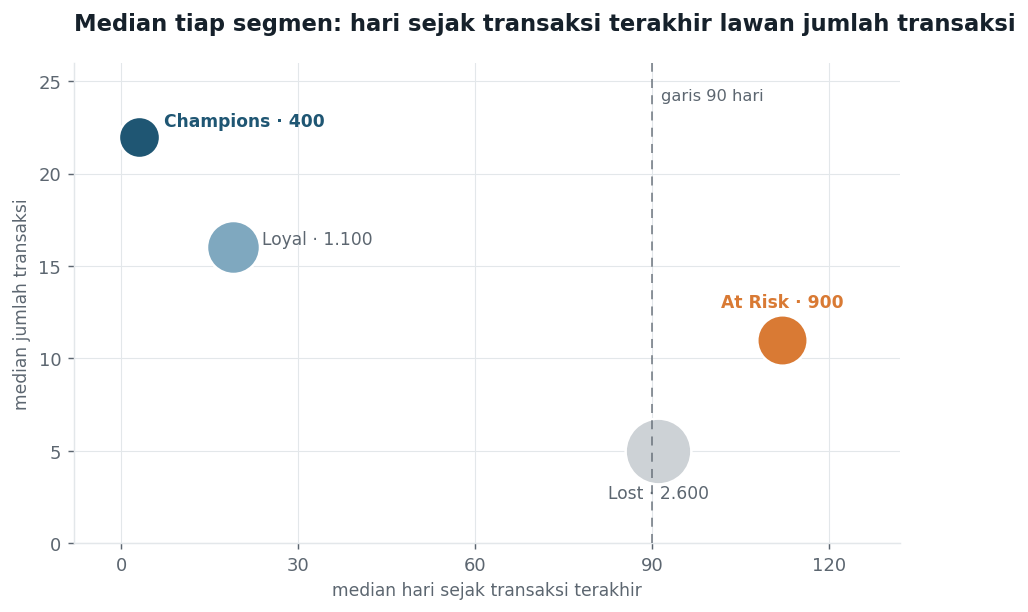

In [11]:
d = profil_segmen.set_index("Segment")

fig, ax = plt.subplots(figsize=(8.2, 4.8))
warna = {"Champions": PETROL, "At Risk": AMBER, "Loyal": PETROL_MUDA, "Lost": SLATE_MUDA}
offset = {"Champions": (14, 6), "Loyal": (16, 2), "At Risk": (0, 18), "Lost": (0, -26)}

ax.axvline(90, color=TEKS_LEMBUT, linewidth=1.0, linestyle=(0, (5, 4)),
           zorder=4, alpha=0.75)
ax.text(91.5, 24.6, "garis 90 hari", fontsize=9, color=TEKS_LEMBUT, va="top")

for s in URUTAN:
    n, r, f = d.loc[s, "pelanggan"], d.loc[s, "median_R"], d.loc[s, "median_F"]
    # Ukuran bulatan sengaja diredam dengan akar supaya bulatan besar tidak
    # menelan yang lain. Dinyatakan di keterangan gambar.
    ax.scatter(r, f, s=(n ** 0.5) * 26, color=warna[s],
               edgecolor="white", linewidth=1.4, zorder=3)
    dx, dy = offset[s]
    tebal = "bold" if s in ("Champions", "At Risk") else "normal"
    ax.annotate(f"{s} · {n:,}".replace(",", "."), (r, f),
                textcoords="offset points", xytext=(dx, dy), fontsize=9.5,
                color=warna[s] if tebal == "bold" else TEKS_LEMBUT,
                fontweight=tebal, ha="left" if dx > 0 else "center")

ax.set_xlim(-8, 132); ax.set_ylim(0, 26); ax.set_xticks([0, 30, 60, 90, 120])
ax.set_xlabel("median hari sejak transaksi terakhir", fontsize=9.5)
ax.set_ylabel("median jumlah transaksi", fontsize=9.5)
ax.set_title("Median tiap segmen: hari sejak transaksi terakhir lawan jumlah transaksi",
             fontsize=12.5, fontweight="bold", pad=18, loc="left", color=TEKS)
for sisi in ["top", "right"]: ax.spines[sisi].set_visible(False)
ax.grid(color=GARIS, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
fig.savefig("gambar_2_median.png"); plt.show()

*Apa yang tergambar:* median hari sejak transaksi terakhir (mendatar) lawan median jumlah
transaksi (tegak) tiap segmen. Lingkaran yang lebih besar berarti segmen yang lebih banyak
orangnya, tetapi **ukurannya sengaja diredam** supaya bulatan besar tidak menelan bulatan
lain, jadi bacalah sebagai perbandingan luas, bukan skala tepat. Jumlah persisnya tertulis
di tiap label.

*Rentang datanya:* 5.000 pelanggan dari 48.130 transaksi bersih, dihitung per 2026-03-31.

*Yang terlihat:* bulatan At Risk duduk jelas di kanan garis 90 hari dan bertahan di 11
transaksi; bulatan Lost duduk tepat di garis itu, di 5 transaksi.

### Gambar 3: seberapa terkonsentrasi nilainya sebenarnya

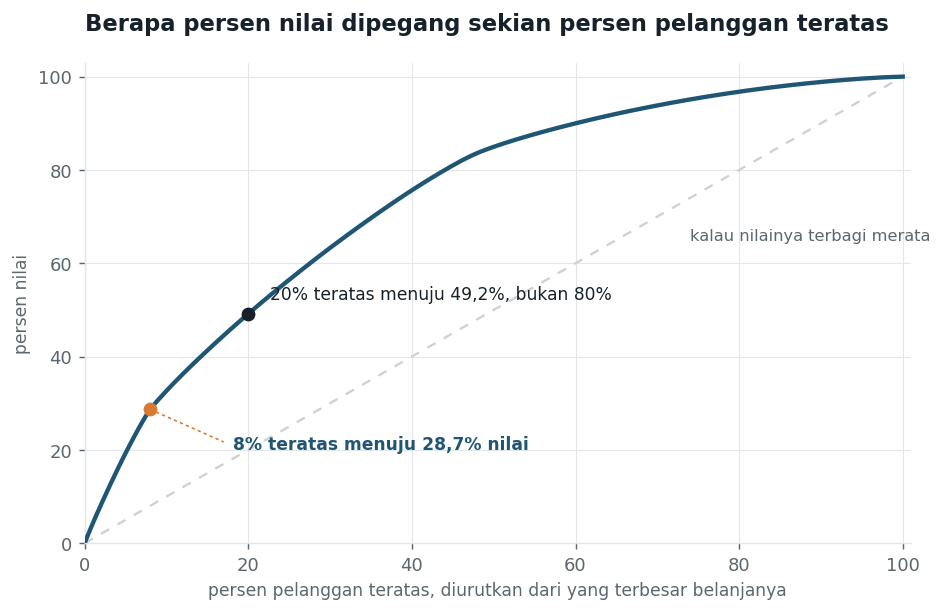

8% teratas  -> 28.7% nilai
20% teratas -> 49.2% nilai


In [12]:
kurva = q("""
WITH urut AS (
    SELECT row_number() OVER (ORDER BY Monetary DESC) AS peringkat,
           sum(Monetary) OVER (ORDER BY Monetary DESC
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS nilai_kumulatif,
           (SELECT count(*)     FROM rfm_segmented) AS n,
           (SELECT sum(Monetary) FROM rfm_segmented) AS total
    FROM rfm_segmented
)
SELECT peringkat * 100.0 / n AS pct_pelanggan,
       nilai_kumulatif * 100.0 / total AS pct_nilai,
       peringkat
FROM urut ORDER BY peringkat
""")

titik = kurva.set_index("peringkat").loc[[400, 1000]]
x8,  y8  = titik.loc[400,  "pct_pelanggan"], titik.loc[400,  "pct_nilai"]
x20, y20 = titik.loc[1000, "pct_pelanggan"], titik.loc[1000, "pct_nilai"]

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot([0, 100], [0, 100], linestyle=(0, (4, 4)), color=SLATE_MUDA, linewidth=1.3, zorder=2)
ax.text(74, 65, "kalau nilainya terbagi merata", fontsize=9, color=TEKS_LEMBUT)
ax.plot(kurva.pct_pelanggan, kurva.pct_nilai, color=PETROL, linewidth=2.4, zorder=3)

ax.scatter([x20], [y20], s=44, color=TEKS, zorder=4)
ax.annotate(f"20% teratas menuju {y20:.1f}%, bukan 80%".replace(".", ","),
            (x20, y20), textcoords="offset points", xytext=(12, 8), fontsize=9.5, color=TEKS)
ax.scatter([x8], [y8], s=44, color=AMBER, zorder=4)
ax.plot([x8, x8 + 9], [y8, y8 - 7], color=AMBER, linewidth=0.9,
        linestyle=(0, (2, 2)), zorder=3)
ax.annotate(f"8% teratas menuju {y8:.1f}% nilai".replace(".", ","),
            (x8 + 9, y8 - 7), textcoords="offset points", xytext=(5, -4),
            fontsize=9.5, color=PETROL, fontweight="bold")

ax.set_xlim(0, 101); ax.set_ylim(0, 103)
ax.set_xlabel("persen pelanggan teratas, diurutkan dari yang terbesar belanjanya", fontsize=9.5)
ax.set_ylabel("persen nilai", fontsize=9.5)
ax.set_title("Berapa persen nilai dipegang sekian persen pelanggan teratas",
             fontsize=12.5, fontweight="bold", pad=18, loc="left", color=TEKS)
for sisi in ["top", "right"]: ax.spines[sisi].set_visible(False)
ax.grid(color=GARIS, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
fig.savefig("gambar_3_konsentrasi.png"); plt.show()

print(f"8% teratas  -> {y8:.1f}% nilai")
print(f"20% teratas -> {y20:.1f}% nilai")

*Apa yang tergambar:* pangsa nilai kumulatif terhadap pangsa pelanggan kumulatif, dengan
5.000 pelanggan diurutkan dari yang terbesar belanjanya.

*Rentang datanya:* 48.130 transaksi bersih, dihitung per 2026-03-31.

*Yang terlihat:* jarak kurva biru terhadap garis putus-putus adalah ukuran
konsentrasinya. Pada 20% pelanggan teratas kurva itu mendarat di 49,2%, bukan di 80%
seperti yang biasa diasumsikan.

Gambar ini mendahului satu bantahan yang hampir pasti diajukan: *"angka 28,7% itu artefak
dari garis yang kamu tarik sendiri."* Kurvanya sudah menyimpang dari garis merata **jauh
sebelum satu ambang pun ditarik**, jadi konsentrasinya sifat sebaran datanya, bukan akibat
garis segmen.

## 6. Variasi tanggal acuan: 2025-12-31

Pertanyaan yang diajukan pemegang anggaran: kalau analisis ini dijalankan tiga bulan lebih
awal, seperti apa pembagian segmennya, dan apakah rekomendasinya berubah.

**Dua tempat harus ikut berganti, bukan satu:** batas atas tanggal di pembersihan, dan
tanggal acuan di perhitungan Recency. Mengganti salah satunya saja menghasilkan angka
lain, dan itu sendiri diagnosis yang berguna.

**Dugaan yang ditulis sebelum kuerinya dijalankan:** Champions mengecil, karena syaratnya
menuntut F ≥ 15 dan M > Rp 5 juta sekaligus dan memotong tiga bulan memotong akumulasi
keduanya. Lost membesar. Arah At Risk tidak jelas. Loyal tidak diduga sama sekali.

**Catatan jendela.** Untuk tanggal acuan ini jendela 15 bulan mundur ke 2024-10-01, sebelum data
dimulai, sehingga riwayat yang tersedia hanya 12 bulan, tiga bulan lebih pendek daripada per
2026-03-31. Pengaruh selisih panjang riwayat ini diukur langsung di bawah, bukan diasumsikan.

In [13]:
con.execute("""
CREATE OR REPLACE TABLE seg_des AS
SELECT *,
    CASE
        WHEN Recency <= 30 AND Frequency >= 15 AND Monetary > 5000000 THEN 'Champions'
        WHEN Recency <= 90 AND Frequency >= 8                          THEN 'Loyal'
        WHEN Recency >  90 AND Frequency >= 5                          THEN 'At Risk'
        ELSE 'Lost'
    END AS Segment
FROM (
    SELECT CustomerID,
           (DATE '2025-12-31' - max(TransactionDate)) AS Recency,   -- ganti 1 dari 2
           count(*)        AS Frequency,
           sum(TotalValue) AS Monetary
    FROM deduped
    WHERE TotalValue IS NOT NULL AND TotalValue > 0
      AND TransactionDate <= DATE '2025-12-31'                      -- ganti 2 dari 2
      AND TransactionDate >= CAST(DATE '2025-12-31' + 1 - INTERVAL 15 MONTH AS DATE)  -- ikut acuan
    GROUP BY CustomerID
);
""")

q("""
SELECT
    m.Segment                                   AS segmen,
    m.n                                         AS per_2026_03_31,
    d.n                                         AS per_2025_12_31,
    d.n - m.n                                   AS selisih
FROM (SELECT Segment, count(*) n FROM rfm_segmented GROUP BY Segment) m
JOIN (SELECT Segment, count(*) n FROM seg_des      GROUP BY Segment) d USING (Segment)
ORDER BY m.n DESC
""")

,segmen,per_2026_03_31,per_2025_12_31,selisih
0,Lost,2600,2469,-131
1,Loyal,1100,2222,1122
2,At Risk,900,226,-674
3,Champions,400,83,-317


**Selisih dugaan dan hasil, dicatat apa adanya.** Dugaan Champions benar, dan jauh lebih
ekstrem daripada yang diduga. Dugaan Lost **salah**; Lost justru sedikit mengecil. Dugaan
"arah At Risk tidak jelas" ternyata terlalu berhati-hati: arahnya sangat jelas dan sangat
besar, hanya ke arah yang tidak dipertimbangkan. Loyal, yang tidak diduga sama sekali,
adalah segmen yang paling berubah, dan perubahannya membalik seluruh cerita.

**Mekanismenya ada tiga, dan ketiganya bercampur di tabel di atas.**

1. *Panjang riwayat.* Per 2025-12-31 hanya ada 12 bulan data, per 2026-03-31 ada 15 bulan.
   Frequency dan Monetary hanya bisa naik seiring riwayat memanjang.
2. *Penuaan Recency.* Recency diukur relatif terhadap tanggal acuan; orang yang berhenti belanja
   di Desember belum sempat menua melewati 90 hari per 2025-12-31.
3. *Perilaku Q1 2026 yang memang berubah.* Sebagian pelanggan berhenti bertransaksi, dan sebagian
   yang bertahan belanja lebih sering daripada sebelumnya.

Efek pertama adalah artefak pengukuran, dua lainnya bukan. Efek pertama bisa dipisahkan dengan
menyamakan panjang jendela di kedua tanggal, 12 bulan masing-masing, dan itulah yang dilakukan
kueri berikut.

In [14]:
con.execute("""
CREATE OR REPLACE MACRO rfm_jendela(acuan, awal) AS TABLE
SELECT CustomerID,
       CASE WHEN (acuan - max(TransactionDate)) <= 30 AND count(*) >= 15
                 AND sum(TotalValue) > 5000000                       THEN 'Champions'
            WHEN (acuan - max(TransactionDate)) <= 90 AND count(*) >= 8  THEN 'Loyal'
            WHEN (acuan - max(TransactionDate)) >  90 AND count(*) >= 5  THEN 'At Risk'
            ELSE 'Lost' END AS Segment
FROM positive_filtered
WHERE TransactionDate BETWEEN awal AND acuan
GROUP BY CustomerID;
""")

# Jendela sama panjang, 12 bulan, di kedua tanggal acuan.
con.execute("""
CREATE OR REPLACE TABLE seg_des12 AS SELECT * FROM rfm_jendela(DATE '2025-12-31', DATE '2025-01-01');
CREATE OR REPLACE TABLE seg_mar12 AS SELECT * FROM rfm_jendela(DATE '2026-03-31', DATE '2025-04-01');
""")
display(q("""
SELECT m.Segment AS segmen,
       m.n  AS mar_15_bulan_resmi,
       m12.n AS mar_12_bulan,
       d.n  AS des_12_bulan
FROM      (SELECT Segment, count(*) n FROM rfm_segmented GROUP BY 1) m
LEFT JOIN (SELECT Segment, count(*) n FROM seg_mar12     GROUP BY 1) m12 USING (Segment)
LEFT JOIN (SELECT Segment, count(*) n FROM seg_des12     GROUP BY 1) d   USING (Segment)
ORDER BY m.n DESC
"""))
display(q("""
SELECT count(*) AS loyal_ke_at_risk_jendela_sama
FROM seg_des12 d JOIN seg_mar12 m USING (CustomerID)
WHERE d.Segment = 'Loyal' AND m.Segment = 'At Risk'
"""))
# Untuk 857 orang Loyal -> At Risk versi resmi: apakah F dan M mereka identik di kedua tanggal?
q("""
SELECT count(*)                                         AS loyal_ke_at_risk,
       count(*) FILTER (WHERE d.Frequency = m.Frequency) AS F_identik,
       count(*) FILTER (WHERE d.Monetary  = m.Monetary)  AS M_identik
FROM seg_des d JOIN rfm_segmented m USING (CustomerID)
WHERE d.Segment = 'Loyal' AND m.Segment = 'At Risk'
""")

,segmen,mar_15_bulan_resmi,mar_12_bulan,des_12_bulan
0,Lost,2600,2586,2469
1,Loyal,1100,1117,2222
2,At Risk,900,892,226
3,Champions,400,377,83


,loyal_ke_at_risk_jendela_sama
0,850


,loyal_ke_at_risk,F_identik,M_identik
0,857,857,857


Dengan jendela sama panjang, Champions per 2026-03-31 menjadi **377**, bukan 400. Dari
kenaikan 83 ke 400, hanya sekitar 23 orang yang berasal dari riwayat yang lebih panjang; sisanya
perilaku Q1 2026. Dugaan awal bahwa Champions "runtuh" per 2025-12-31 karena akumulasinya terpotong
ternyata hanya benar sebagian kecil.

Temuan utama bagian ini justru menguat. Perpindahan Loyal ke At Risk tetap **850** dengan jendela
sama panjang, dan untuk 857 orang versi resmi, Frequency dan Monetary-nya **identik** di kedua
tanggal: mereka tidak bertransaksi sama sekali sesudah 2025-12-30, jadi tidak ada akumulasi yang
bisa berbeda. Perpindahan mereka murni perilaku, bukan artefak jendela.

Pelajarannya untuk segmentasi ulang tiap kuartal: perbandingan antar-tanggal hanya sah bila panjang
jendelanya sama, dan itulah alasan jendela 15 bulan dikunci di Bagian 3.

### Gambar: hasil segmentasi terjangkar pada tanggalnya

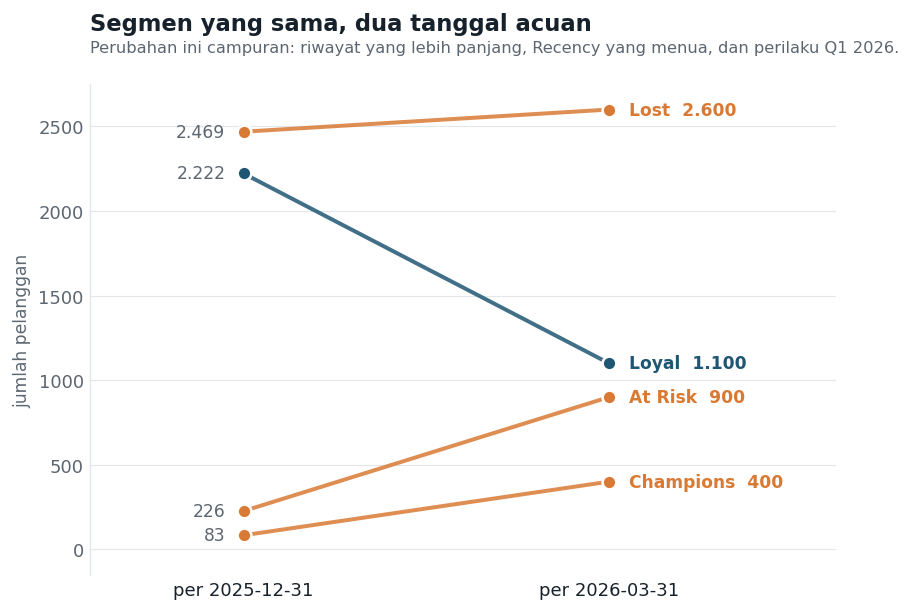

In [15]:
d = q("""
SELECT s.Segment AS segmen, s.n AS maret, x.n AS desember FROM
  (SELECT Segment, count(*) n FROM rfm_segmented GROUP BY Segment) s
  JOIN (SELECT Segment, count(*) n FROM seg_des GROUP BY Segment) x USING (Segment)
""").set_index("segmen")

fig, ax = plt.subplots(figsize=(7.4, 4.9))
for s in URUTAN:
    des, mar = d.loc[s, "desember"], d.loc[s, "maret"]
    w = AMBER if mar > des else PETROL
    ax.plot([0, 1], [des, mar], color=w, linewidth=2.2, zorder=2, alpha=.85)
    ax.scatter([0, 1], [des, mar], s=58, color=w, zorder=3,
               edgecolor="white", linewidth=1.4)
    ax.annotate(f"{des:,}".replace(",", "."), (0, des), textcoords="offset points",
                xytext=(-10, 0), ha="right", va="center", fontsize=9.5, color=TEKS_LEMBUT)
    ax.annotate(f"{s}  {mar:,}".replace(",", "."), (1, mar), textcoords="offset points",
                xytext=(11, 0), ha="left", va="center", fontsize=9.5,
                color=w, fontweight="bold")

ax.set_xlim(-.42, 1.62); ax.set_ylim(-150, 2750)
ax.set_xticks([0, 1]); ax.set_xticklabels(["per 2025-12-31", "per 2026-03-31"],
                                          fontsize=10, color=TEKS)
ax.set_ylabel("jumlah pelanggan", fontsize=9.5)
ax.set_title("Segmen yang sama, dua tanggal acuan",
             fontsize=12.5, fontweight="bold", pad=30, loc="left", color=TEKS)
ax.text(0, 1.065, "Perubahan ini campuran: riwayat yang lebih panjang, Recency yang menua, "
                  "dan perilaku Q1 2026.",
        transform=ax.transAxes, fontsize=9, color=TEKS_LEMBUT)
for sisi in ["top", "right", "bottom"]: ax.spines[sisi].set_visible(False)
ax.grid(axis="y", color=GARIS, linewidth=.6, zorder=0)
ax.set_axisbelow(True); ax.tick_params(length=0)
fig.savefig("gambar_5_variasi_tanggal.png"); plt.show()

*Apa yang tergambar:* jumlah pelanggan tiap segmen pada dua tanggal acuan, dalam orang,
untuk keempat segmen dan populasi 5.000 pelanggan yang sama.

*Rentang datanya:* 39.482 transaksi bersih sampai 2025-12-31, dan 48.130 sampai
2026-03-31, dari tabel mentah yang sama.

*Yang terlihat:* garis Loyal turun sementara tiga garis lain naik.


In [16]:
q("""
SELECT 'Recency'   AS ukuran, quantile_cont(Recency,0.5)   AS median,
       quantile_cont(Recency,0.75) AS q3,  max(Recency)   AS maks FROM seg_des
UNION ALL
SELECT 'Frequency', quantile_cont(Frequency,0.5),
       quantile_cont(Frequency,0.75), max(Frequency) FROM seg_des
UNION ALL
SELECT 'Monetary',  round(quantile_cont(Monetary,0.5)),
       round(quantile_cont(Monetary,0.75)), round(max(Monetary)) FROM seg_des
""")

,ukuran,median,q3,maks
0,Recency,35.0,79.0,350.0
1,Frequency,6.0,12.0,20.0
2,Monetary,1118853.0,2808885.0,7670004.0


## 7. Uji kepekaan ambang

Rekomendasi berdiri di atas ambang yang diakui sebagai keputusan. Seberapa kokoh ia
berdiri kalau keputusannya sedikit berbeda? Uji ini **tidak boleh dinalar, ia
dijalankan.** Geser tiap ambang satu langkah wajar, satu per satu, di atas data bersih
yang sama, lalu hitung berapa pelanggan berpindah **dan** apakah arah rekomendasinya bertahan:
pangsa nilai Champions, pangsa nilai At Risk, dan ukuran sasaran win-back (At Risk yang berjeda
paling lama 30 hari melewati garis Recency).

Tujuh geseran: tiga ambang di versi awal, ditambah empat geseran pada garis yang menentukan
sasaran win-back, yaitu ambang F At Risk dan garis Recency 90 hari yang memisahkan Loyal dari
At Risk.

In [17]:
# Tiap skenario: (r_champ, f_champ, m_champ, r_garis, f_loyal, f_atrisk).
# r_garis memisahkan Loyal (R <= garis) dari At Risk (R > garis).
SKENARIO = [
    ("resmi",                              30, 15, 5000000,  90, 8, 5),
    ("Recency Champions 30 ke 45 hari",    45, 15, 5000000,  90, 8, 5),
    ("Frequency Loyal 8 ke 6 transaksi",   30, 15, 5000000,  90, 6, 5),
    ("Monetary Champions Rp 5 jt ke 4 jt", 30, 15, 4000000,  90, 8, 5),
    ("Frequency At Risk 5 ke 4 transaksi", 30, 15, 5000000,  90, 8, 4),
    ("Frequency At Risk 5 ke 6 transaksi", 30, 15, 5000000,  90, 8, 6),
    ("Garis Recency 90 ke 75 hari",        30, 15, 5000000,  75, 8, 5),
    ("Garis Recency 90 ke 105 hari",       30, 15, 5000000, 105, 8, 5),
]

def kueri_skenario(nama, rc, fc, mc, rg, fl, fa):
    return f"""
    SELECT '{nama}' AS skenario,
           count(*) FILTER (WHERE s <> resmi)                                     AS pindah,
           count(*) FILTER (WHERE s = 'Champions')                               AS champions,
           round(sum(Monetary) FILTER (WHERE s = 'Champions') * 100.0 / sum(Monetary), 1) AS pangsa_nilai_champions,
           count(*) FILTER (WHERE s = 'At Risk')                                 AS at_risk,
           round(sum(Monetary) FILTER (WHERE s = 'At Risk') * 100.0 / sum(Monetary), 1)   AS pangsa_nilai_at_risk,
           count(*) FILTER (WHERE s = 'At Risk' AND Recency <= {rg} + 30)        AS sasaran_winback,
           round(sum(Monetary) FILTER (WHERE s = 'At Risk' AND Recency <= {rg} + 30) / 1e9, 2) AS nilai_sasaran_miliar
    FROM (
        SELECT Monetary, Recency, Segment AS resmi,
               CASE WHEN Recency <= {rc} AND Frequency >= {fc} AND Monetary > {mc} THEN 'Champions'
                    WHEN Recency <= {rg} AND Frequency >= {fl}                    THEN 'Loyal'
                    WHEN Recency >  {rg} AND Frequency >= {fa}                    THEN 'At Risk'
                    ELSE 'Lost' END AS s
        FROM rfm_segmented
    )"""

kepekaan = q(" UNION ALL ".join(kueri_skenario(*s) for s in SKENARIO))
kepekaan

,skenario,pindah,champions,pangsa_nilai_champions,at_risk,pangsa_nilai_at_risk,sasaran_winback,nilai_sasaran_miliar
0,resmi,0,400,28.7,900,24.7,552,1.70
1,Recency Champions 30 ke 45 hari,0,400,28.7,900,24.7,552,1.70
2,Frequency Loyal 8 ke 6 transaksi,824,400,28.7,900,24.7,552,1.70
3,Monetary Champions Rp 5 jt ke 4 jt,52,452,30.7,900,24.7,552,1.70
4,Frequency At Risk 5 ke 4 transaksi,389,400,28.7,1289,26.9,654,1.77
5,Frequency At Risk 5 ke 6 transaksi,0,400,28.7,900,24.7,552,1.70
6,Garis Recency 90 ke 75 hari,132,400,28.7,1032,26.0,486,1.24
7,Garis Recency 90 ke 105 hari,354,400,28.7,546,14.8,361,1.10


Hasilnya **membalik dugaan yang wajar**, dan inilah kenapa uji ini dijalankan alih-alih
dinalar. **Ambang-ambang ini sama sekali tidak sama bobotnya.**

Menaikkan Recency Champions 50%, dari 30 ke 45 hari, tidak memindahkan seorang pun. Sebabnya
terbaca di profil segmen: median Recency Champions 3 hari, jauh di dalam ambang mana pun yang
wajar. Menaikkan ambang F At Risk dari 5 ke 6 juga tidak memindahkan siapa pun, karena tidak ada
pelanggan At Risk dengan tepat 5 transaksi.

Sebaliknya menurunkan Frequency Loyal dua langkah memindahkan **824 pelanggan**, hampir seperenam
populasi, karena garisnya berdiri tepat di kerumunan: median Frequency populasi 7, ambangnya 8.
Garis Recency 90 hari juga menanggung beban: menggesernya ke 105 hari memindahkan 354 orang dan
mengecilkan At Risk dari 900 ke 546; menurunkan ambang F At Risk ke 4 memindahkan 389 orang.

**Arah rekomendasinya, kali ini dihitung, bukan dinalar.** Di ketujuh geseran, Champions tetap
memegang 28,7% sampai 30,7% nilai dengan paling banyak 9% pelanggan, dan kelompok At Risk yang
baru menjauh tetap ada: 361 sampai 654 orang dengan nilai historis Rp 1,10 miliar sampai
Rp 1,77 miliar. Yang berubah hanya ukurannya. Garis yang paling menggeser **sasaran** win-back adalah garis Recency, bukan
ambang F, dan itu alasan sasaran ditulis sebagai "berjeda paling lama satu bulan melewati garis",
bukan sebagai angka 552 yang dianggap pasti.

Akibatnya langsung pada cara menulis catatan keputusan: ambang yang tidak menanggung beban boleh
disebut sekilas; ambang yang menanggung ratusan pelanggan **wajib** dibela dengan alasan yang kuat,
karena di situlah pemeriksa akan menekan.

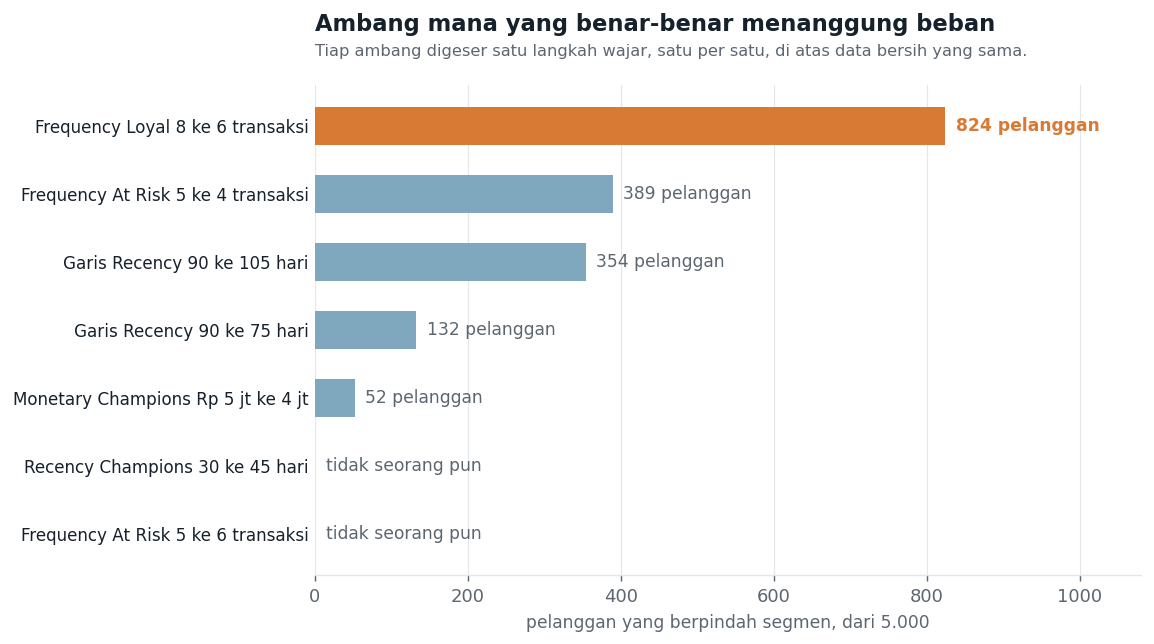

In [18]:
d = kepekaan[kepekaan.skenario != "resmi"].sort_values("pindah", ascending=False)

fig, ax = plt.subplots(figsize=(8.2, 4.9))
warna = [AMBER if v > 500 else PETROL_MUDA if v > 0 else SLATE_MUDA for v in d.pindah]
ax.barh(range(len(d)), d.pindah, color=warna, height=.56, zorder=3)
for i, v in enumerate(d.pindah):
    label = f"{v:,} pelanggan".replace(",", ".") if v else "tidak seorang pun"
    ax.text(v + 14, i, label, va="center", fontsize=9.5,
            color=AMBER if v > 500 else TEKS_LEMBUT,
            fontweight="bold" if v > 500 else "normal")
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.skenario, fontsize=9.3, color=TEKS)
ax.invert_yaxis(); ax.set_xlim(0, 1080)
ax.set_xlabel("pelanggan yang berpindah segmen, dari 5.000", fontsize=9.5)
ax.set_title("Ambang mana yang benar-benar menanggung beban",
             fontsize=12.5, fontweight="bold", pad=30, loc="left", color=TEKS)
ax.text(0, 1.06, "Tiap ambang digeser satu langkah wajar, satu per satu, "
                  "di atas data bersih yang sama.",
        transform=ax.transAxes, fontsize=9, color=TEKS_LEMBUT)
for sisi in ["top", "right", "left"]: ax.spines[sisi].set_visible(False)
ax.grid(axis="x", color=GARIS, linewidth=.6, zorder=0)
ax.set_axisbelow(True); ax.tick_params(axis="y", length=0)
fig.savefig("gambar_7_kepekaan_ambang.png"); plt.show()

*Apa yang tergambar:* jumlah pelanggan yang berpindah segmen ketika satu ambang digeser
satu langkah wajar, dalam orang, dari populasi 5.000, untuk tujuh geseran.

*Rentang datanya:* 48.130 transaksi bersih, dihitung per 2026-03-31, dengan ambang lain dibiarkan
tetap di tiap baris.

*Yang terlihat:* batang teratas lebih dari dua kali panjang batang kedua, dan dua batang terbawah
tidak punya panjang sama sekali.

## 8. Matriks perpindahan antar kedua tanggal

Menggabungkan kedua segmentasi per pelanggan menghasilkan sesuatu yang **tidak terlihat
dari satu tanggal mana pun**.

In [19]:
matriks = q("""
SELECT d.Segment AS dari_2025_12_31,
       m.Segment AS ke_2026_03_31,
       count(*)  AS pelanggan
FROM seg_des d
JOIN rfm_segmented m USING (CustomerID)
GROUP BY 1, 2
ORDER BY pelanggan DESC
""")
display(matriks)

# aritmetika silang matriks
periksa = q("""
SELECT m.Segment AS segmen, sum(x.pelanggan) AS dari_matriks, max(m.n) AS dari_segmentasi
FROM (SELECT Segment, count(*) n FROM rfm_segmented GROUP BY Segment) m
JOIN (SELECT m2.Segment, count(*) pelanggan
      FROM seg_des d2 JOIN rfm_segmented m2 USING (CustomerID)
      GROUP BY d2.Segment, m2.Segment) x ON x.Segment = m.Segment
GROUP BY m.Segment
""")
display(periksa)
assert (periksa.dari_matriks == periksa.dari_segmentasi).all(), "Matriks bocor"
print("Matriks utuh: tidak ada pelanggan yang bocor atau terhitung dua kali.")

,dari_2025_12_31,ke_2026_03_31,pelanggan
0,Lost,Lost,2468
1,Loyal,Loyal,1060
2,Loyal,At Risk,857
3,Loyal,Champions,305
4,At Risk,Lost,132
5,Champions,Champions,83
6,At Risk,At Risk,43
7,At Risk,Loyal,40
8,At Risk,Champions,11
9,Lost,Champions,1


,segmen,dari_matriks,dari_segmentasi
0,Loyal,1100.0,1100
1,Lost,2600.0,2600
2,Champions,400.0,400
3,At Risk,900.0,900


Matriks utuh: tidak ada pelanggan yang bocor atau terhitung dua kali.


**Temuannya.** Dari 900 pelanggan At Risk per 2026-03-31, sebanyak **857 (95,2%) masih
tergolong Loyal tiga bulan sebelumnya.** Segmen At Risk bukan kolam lama yang mengendap,
melainkan kohort yang baru terbentuk dalam satu kuartal.

Ini mengubah bobot rekomendasi win-back. Mereka bukan orang yang sudah lama pergi,
melainkan orang yang baru saja berhenti.

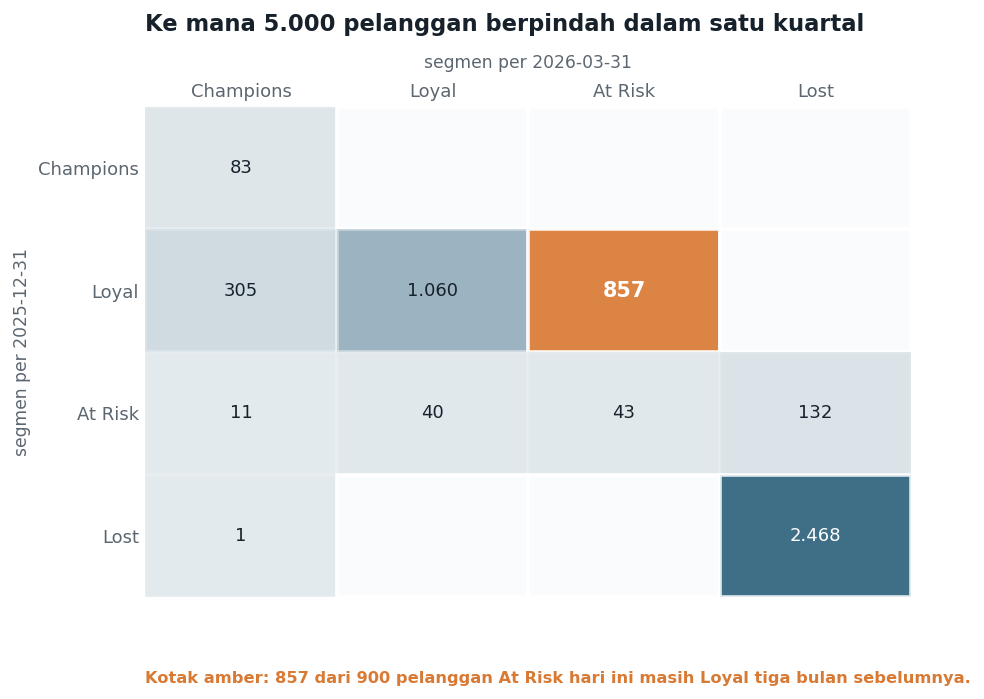

In [20]:
pivot = {(r.dari_2025_12_31, r.ke_2026_03_31): r.pelanggan for r in matriks.itertuples()}

fig, ax = plt.subplots(figsize=(7.6, 4.9))
for i, dari in enumerate(URUTAN):
    for j, ke in enumerate(URUTAN):
        n = pivot.get((dari, ke), 0)
        if n == 0:
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor="#FAFBFC",
                                   edgecolor="white", linewidth=2)); continue
        sorot = (dari == "Loyal" and ke == "At Risk")
        alpha = .92 if sorot else min(.12 + (n / 2600) * .78, .9)
        ax.add_patch(Rectangle((j, i), 1, 1, facecolor=AMBER if sorot else PETROL,
                               alpha=alpha, edgecolor="white", linewidth=2))
        ax.text(j + .5, i + .5, f"{n:,}".replace(",", "."), ha="center", va="center",
                fontsize=11.5 if sorot else 10,
                fontweight="bold" if sorot else "normal",
                color="white" if alpha > .55 else TEKS)

ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.invert_yaxis()
ax.set_xticks([x + .5 for x in range(4)]); ax.set_xticklabels(URUTAN, fontsize=10)
ax.set_yticks([y + .5 for y in range(4)]); ax.set_yticklabels(URUTAN, fontsize=10)
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
ax.set_xlabel("segmen per 2026-03-31", fontsize=9.5, labelpad=8)
ax.set_ylabel("segmen per 2025-12-31", fontsize=9.5)
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("Ke mana 5.000 pelanggan berpindah dalam satu kuartal",
             fontsize=12.5, fontweight="bold", pad=42, loc="left", color=TEKS)
ax.text(0, -.175, "Kotak amber: 857 dari 900 pelanggan At Risk hari ini "
                  "masih Loyal tiga bulan sebelumnya.",
        transform=ax.transAxes, fontsize=9, color=AMBER, fontweight="bold")
fig.savefig("gambar_4_perpindahan.png"); plt.show()

*Apa yang tergambar:* jumlah pelanggan untuk tiap pasangan segmen asal dan segmen tujuan,
dalam orang, dari populasi 5.000 yang sama di kedua tanggal.

*Rentang datanya:* segmentasi per 2025-12-31 (baris) dibandingkan dengan segmentasi per
2026-03-31 (kolom), keduanya dari tabel mentah yang sama.

*Yang terlihat:* kotak paling terang di baris Loyal jatuh di kolom At Risk, dan kotak
At Risk ke At Risk hanya memuat 43 orang.


In [21]:
q(f"""
SELECT
    CASE WHEN Recency <= 120 THEN 'a. 91 sampai 120 hari'
         WHEN Recency <= 180 THEN 'b. 121 sampai 180 hari'
         WHEN Recency <= 270 THEN 'c. 181 sampai 270 hari'
         ELSE                     'd. lebih dari 270 hari' END AS sejak_transaksi_terakhir,
    count(*)               AS pelanggan,
    round(sum(Monetary))   AS nilai_historis,
    min(DATE '{ACUAN}' - CAST(Recency AS INTEGER)) AS transaksi_terakhir_paling_awal,
    max(DATE '{ACUAN}' - CAST(Recency AS INTEGER)) AS transaksi_terakhir_paling_akhir
FROM rfm_segmented
WHERE Segment = 'At Risk'
GROUP BY 1 ORDER BY 1
""")

,sejak_transaksi_terakhir,pelanggan,nilai_historis,transaksi_terakhir_paling_awal,transaksi_terakhir_paling_akhir
0,a. 91 sampai 120 hari,552,1.699996e+09,2025-12-01,2025-12-30
1,b. 121 sampai 180 hari,305,9.130747e+08,2025-10-02,2025-11-30
2,c. 181 sampai 270 hari,42,1.259638e+08,2025-07-16,2025-10-01
3,d. lebih dari 270 hari,1,2.268846e+06,2025-06-06,2025-06-06


In [22]:
q("""
SELECT date_trunc('quarter', TransactionDate) AS kuartal,
       count(*)                   AS transaksi,
       count(DISTINCT CustomerID) AS pelanggan_aktif,
       round(sum(TotalValue))     AS nilai
FROM cleaned_data
GROUP BY 1 ORDER BY 1
""")

,kuartal,transaksi,pelanggan_aktif,nilai
0,2025-01-01,9803,3953,2.191193e+09
1,2025-04-01,9704,3935,2.207956e+09
2,2025-07-01,10057,4013,2.281104e+09
3,2025-10-01,9918,3954,2.236308e+09
4,2026-01-01,8648,2789,2.184162e+09


Konteks kuartalan menguatkan dari arah lain. Empat kuartal stabil di sekitar 3.950
pelanggan aktif, lalu Q1 2026 turun ke 2.789, turun 29,5% dibanding Q4 2025. Perhatikan bahwa nilainya
nyaris tidak bergerak dan transaksinya hanya turun 12,8%: pelanggan yang tersisa
berbelanja lebih banyak masing-masing. Q1 2026 adalah kuartal lengkap di data bersih, jadi
ini bukan artefak pemotongan tanggal acuan.

**Batas temuan ini, dinyatakan tegas.** Data menunjukkan **bahwa** sebuah kohort besar
berhenti bertransaksi di Q1 2026. Ia **tidak** menunjukkan kenapa. Dan hanya ada satu
pasang tanggal untuk dibandingkan, sehingga tidak ada pembanding historis yang memberi
tahu apakah laju 38,6% (857 dari 2.222 Loyal) tinggi atau normal bagi bisnis ini. Klaim
yang bisa dipertahankan berhenti di: terjadi, sebesar ini, pada periode ini.

Kelompok 552 orang yang dipakai sebagai sasaran win-back terakhir bertransaksi antara 2025-12-01
dan 2025-12-30 (tabel di atas): mereka berhenti sejak Desember 2025 dan tidak muncul sama sekali
sepanjang Q1 2026.

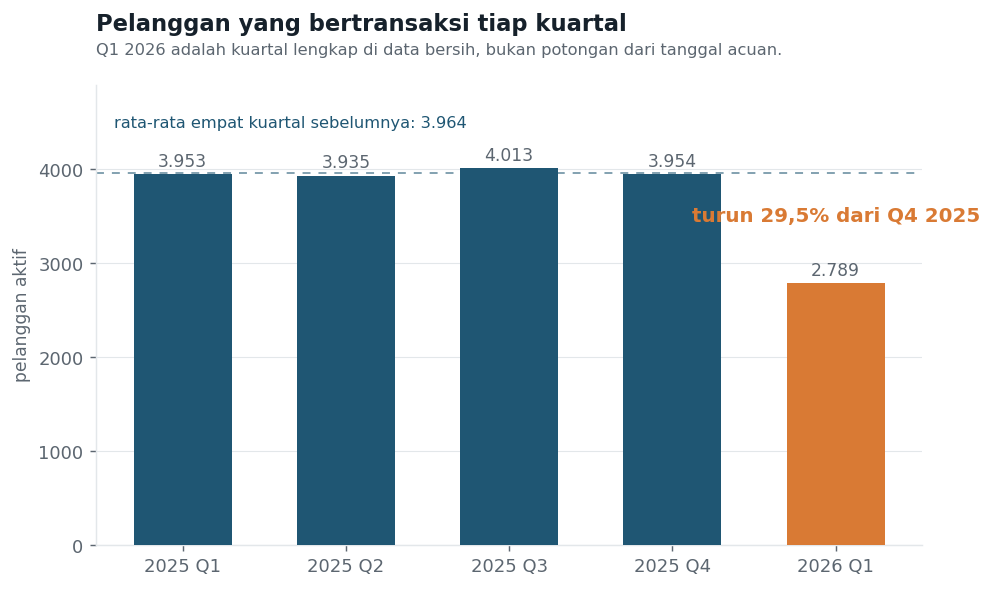

In [23]:
d = q("""
WITH k AS (
    SELECT date_trunc('quarter', TransactionDate) AS awal,
           cast(year(TransactionDate) AS VARCHAR) || ' Q' ||
           cast(quarter(TransactionDate) AS VARCHAR) AS kuartal,
           count(DISTINCT CustomerID) AS pelanggan_aktif
    FROM cleaned_data GROUP BY 1, 2
)
SELECT kuartal, pelanggan_aktif,
       avg(pelanggan_aktif) FILTER (WHERE awal < DATE '2026-01-01') OVER () AS rerata_4_kuartal,
       round((lag(pelanggan_aktif) OVER (ORDER BY awal) - pelanggan_aktif) * 100.0
             / lag(pelanggan_aktif) OVER (ORDER BY awal), 1) AS turun_dari_kuartal_lalu
FROM k ORDER BY awal
""")

fig, ax = plt.subplots(figsize=(8.2, 4.6))
bar = ax.bar(d.kuartal, d.pelanggan_aktif, color=[PETROL]*4 + [AMBER], width=.6, zorder=3)
for b, v in zip(bar, d.pelanggan_aktif):
    ax.text(b.get_x() + b.get_width()/2, v + 80, f"{v:,}".replace(",", "."),
            ha="center", fontsize=9.5, color=TEKS_LEMBUT)
rerata = d.rerata_4_kuartal.iloc[0]
ax.axhline(rerata, color=PETROL, linestyle=(0, (4, 4)), linewidth=1.1, alpha=.55, zorder=2)
ax.text(-0.42, rerata + 480,
        f"rata-rata empat kuartal sebelumnya: {rerata:,.0f}".replace(",", "."),
        fontsize=9, color=PETROL, ha="left")
turun = d.turun_dari_kuartal_lalu.iloc[-1]
ax.annotate(f"turun {turun:.1f}% dari Q4 2025".replace(".", ","), (4, d.pelanggan_aktif.iloc[-1]),
            textcoords="offset points", xytext=(0, 34), ha="center",
            fontsize=11, color=AMBER, fontweight="bold")
ax.set_ylim(0, 4900); ax.set_ylabel("pelanggan aktif", fontsize=9.5)
ax.set_title("Pelanggan yang bertransaksi tiap kuartal",
             fontsize=12.5, fontweight="bold", pad=30, loc="left", color=TEKS)
ax.text(0, 1.065, "Q1 2026 adalah kuartal lengkap di data bersih, bukan potongan "
                  "dari tanggal acuan.", transform=ax.transAxes,
        fontsize=9, color=TEKS_LEMBUT)
for sisi in ["top", "right"]: ax.spines[sisi].set_visible(False)
ax.grid(axis="y", color=GARIS, linewidth=.6, zorder=0); ax.set_axisbelow(True)
fig.savefig("gambar_6_aktivitas_kuartal.png"); plt.show()

*Apa yang tergambar:* jumlah pelanggan berbeda yang bertransaksi pada tiap kuartal, dalam
orang, untuk lima kuartal data bersih.

*Rentang datanya:* 48.130 transaksi bersih, Januari 2025 sampai 31 Maret 2026.

*Yang terlihat:* empat batang pertama berhenti di ketinggian yang hampir sama, lalu batang
kelima berhenti jauh di bawah garis putus-putus rata-ratanya.


### Gambar: di mana nilai At Risk itu duduk

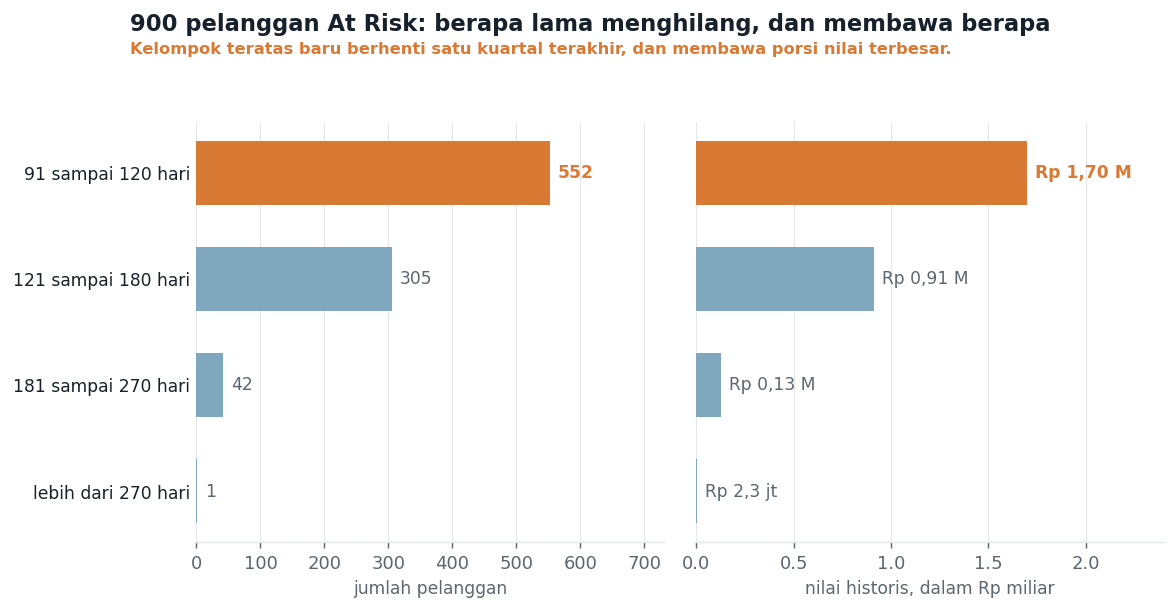

In [24]:
d = q("""
SELECT CASE WHEN Recency<=120 THEN '91 sampai 120 hari'
            WHEN Recency<=180 THEN '121 sampai 180 hari'
            WHEN Recency<=270 THEN '181 sampai 270 hari'
            ELSE 'lebih dari 270 hari' END AS jeda,
       CASE WHEN Recency<=120 THEN 1 WHEN Recency<=180 THEN 2
            WHEN Recency<=270 THEN 3 ELSE 4 END AS urut,
       count(*) AS pelanggan, sum(Monetary)/1e9 AS nilai_miliar
FROM rfm_segmented WHERE Segment='At Risk' GROUP BY 1,2 ORDER BY urut
""")

fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(9.6, 4.2), sharey=True,
                                  gridspec_kw={"wspace": .07})
warna = [AMBER] + [PETROL_MUDA] * (len(d) - 1)

kiri.barh(range(len(d)), d.pelanggan, color=warna, height=.6, zorder=3)
for i, v in enumerate(d.pelanggan):
    kiri.text(v + 12, i, f"{v:,}".replace(",", "."), va="center", fontsize=9.5,
              color=AMBER if i == 0 else TEKS_LEMBUT,
              fontweight="bold" if i == 0 else "normal")
kiri.set_xlim(0, 730); kiri.invert_yaxis()
kiri.set_yticks(range(len(d))); kiri.set_yticklabels(d.jeda, fontsize=9.5, color=TEKS)
kiri.set_xlabel("jumlah pelanggan", fontsize=9.5)

kanan.barh(range(len(d)), d.nilai_miliar, color=warna, height=.6, zorder=3)
for i, v in enumerate(d.nilai_miliar):
    # nilai yang membulat jadi 0,00 miliar bukan nol; tampilkan dalam juta
    lab = f"Rp {v:.2f} M" if v >= 0.01 else f"Rp {v*1000:.1f} jt"
    kanan.text(v + .04, i, lab.replace(".", ","), va="center", fontsize=9.5,
               color=AMBER if i == 0 else TEKS_LEMBUT,
               fontweight="bold" if i == 0 else "normal")
kanan.set_xlim(0, 2.4)
kanan.set_xlabel("nilai historis, dalam Rp miliar", fontsize=9.5)

for a in (kiri, kanan):
    for sisi in ["top", "right", "left"]: a.spines[sisi].set_visible(False)
    a.grid(axis="x", color=GARIS, linewidth=.6, zorder=0)
    a.set_axisbelow(True); a.tick_params(axis="y", length=0)

fig.suptitle("900 pelanggan At Risk: berapa lama menghilang, dan membawa berapa",
             fontsize=12.5, fontweight="bold", x=.072, ha="left", y=1.08)
fig.text(.072, 1.005, "Kelompok teratas baru berhenti satu kuartal terakhir, "
                      "dan membawa porsi nilai terbesar.",
         fontsize=9, color=AMBER, fontweight="bold")
fig.savefig("gambar_8_at_risk_jeda.png"); plt.show()

*Apa yang tergambar:* 900 pelanggan At Risk dipecah menurut lama jeda sejak transaksi
terakhir, dengan jumlah orang di kiri dan nilai historis dalam Rp miliar di kanan.

*Rentang datanya:* 48.130 transaksi bersih, dihitung per 2026-03-31.

*Yang terlihat:* baris teratas memuat lebih dari separuh orangnya dan porsi nilai terbesar
di antara keempat baris, sementara dua baris terbawah hampir tidak punya panjang di kedua
sisi.

Perlu ditegaskan: gambar ini **tidak** membuktikan kelompok teratas lebih mudah
dipulihkan. Tidak ada data respons di tabel ini yang bisa membuktikan hal itu. Yang
ditunjukkan gambar ini hanya di mana taruhan terbesarnya duduk, dan karena itu di mana
sebuah uji berskala kecil akan memberi sinyal paling cepat.


## 9. Temuan

Tiga temuan, diurutkan menurut **bobot keputusan**, bukan menurut urutan
ditemukannya. Secara kronologi kerja, temuan tentang pembersihan data datang paling
dulu: 2.850 baris dibuang sebelum segmen pertama dihitung. Tetapi ujian untuk tiap
kandidat temuan bukan "kapan ia ditemukan" melainkan *keputusan apa yang berubah kalau
temuan ini tidak ada?* Kalau jawabannya "tidak ada yang berubah", ia bukan temuan utama
melainkan bukti pendukung, dan pembersihan masuk kategori itu: ia fondasi, dan fondasi
bekerja dengan tidak tampil.

---

**Nilai pelanggan terkonsentrasi: nyata, tetapi lebih sedang daripada yang biasa
diasumsikan.**
Dari 5.000 pelanggan, 400 orang (8,0%) memegang 28,7% seluruh nilai transaksi, yaitu
3,59 kali lipat porsi seimbangnya, dan kelompok itu masih sangat aktif dengan median 3
hari sejak transaksi terakhir dan median 22 transaksi. Yang tidak berlaku di sini justru
aturan 80/20 yang sering dipinjam: 20% pelanggan teratas memegang 49,2%, bukan 80%.
Konsentrasi ini sifat sebaran datanya, bukan akibat garis segmen, karena kurvanya sudah
menyimpang dari garis merata sebelum satu ambang pun ditarik.

**Nilai yang sebanding sedang berjalan pergi, dan kelompoknya baru terbentuk satu
kuartal terakhir.**
900 pelanggan (18,0%) bermedian 11 transaksi, yang membuktikan mereka pernah rutin, kini
bermedian 112 hari tanpa transaksi. Kelompok ini membawa Rp 2,74 miliar nilai historis,
atau 24,7% dari total, hampir menyamai pangsa kelompok teratas. Menjalankan segmentasi
yang sama pada tanggal acuan tiga bulan lebih awal menunjukkan 857 dari 900 orang itu
masih tergolong Loyal saat itu: ini kohort yang baru berhenti, bukan kolam lama yang
mengendap. Temuan ini tidak bergantung pada panjang jendela: dengan jendela 12 bulan di kedua
tanggal, angkanya 850. Berapa yang bisa dipulihkan tidak diketahui dari data transaksi.

**Mayoritas pelanggan adalah pembeli ringan, bukan pelanggan setia yang hilang.**
2.600 pelanggan (52,0%) bermedian 5 transaksi dan nilai median Rp 0,67 juta, dan mereka terbelah
dua sama besar: 1.300 masih bertransaksi dalam 90 hari terakhir tetapi hanya 5 sampai 7 kali dalam
15 bulan, dan 1.300 sudah lebih dari 90 hari tak terlihat dengan 2 sampai 4 transaksi. Keduanya
profil kebiasaan yang tidak pernah terbentuk, bukan kebiasaan yang putus. Label "Lost" karena itu
terlalu keras untuk separuh pertamanya, dan ini dinyatakan terbuka alih-alih dibiarkan ditemukan
orang lain. Perbedaan itu pula yang menjawab pertanyaan paling tajam, yaitu kenapa lebih dari
separuh pelanggan sengaja tidak mendapat program kuartal ini.

---

Temuan ketiga layak diperhatikan bentuknya. Ia temuan **negatif**, tentang kelompok yang
justru tidak diberi program, dan temuan yang membela bagian rekomendasi paling rawan
diserang selalu layak naik ke urutan utama.

## 10. Uji bantahan

Validasi yang sesungguhnya bukan daftar periksa kerapian. Kueri yang rapi, lengkap, dan
jalan sudah tiga kali terbukti menghasilkan angka yang keliru di modul ini. Bentuk
validasi yang benar: untuk tiap temuan, tanyakan tiga hal. Penjelasan tandingan apa yang
belum disingkirkan. Data apa yang, kalau ada, akan membatalkan temuan ini. Dan seberapa
jauh asumsi di bawahnya boleh digeser sebelum rekomendasinya ikut bergeser.

Temuan yang tidak lolos lebih baik gugur di sini, di hadapan sendiri, daripada gugur di
rapat.

**Bantahan atas temuan pertama: "8,0% memegang 28,7% itu artefak dari garis yang kamu
tarik sendiri. Geser ambangnya, angkanya ikut."**

Setengah benar, dan kekuatan jawabannya datang dari mengakui setengah yang benar itu
lebih dulu. Benar bahwa angka 400 dan 28,7% bergantung pada ambang. Yang **tidak**
bergantung pada ambang adalah bentuk sebarannya: Monetary membentang Rp 44.457 sampai
Rp 10.878.758 dengan median Rp 1.358.137, dan kurva konsentrasi di bagian 5 sudah
menyimpang dari garis merata sebelum satu ambang pun ditarik.

*Data yang akan membatalkan temuan ini, kalau ada:* sebaran Monetary yang datar, dengan
kuartil-kuartil berdekatan dan nilai per pelanggan yang seragam. Data itu tidak ada di
sini, dan menyebutkan fakta itu adalah jawabannya: konsentrasinya ada di data sebelum
garis mana pun ditarik; ambang hanya memberi nama pada kelompok yang memang ada.

**Bantahan atas temuan kedua: "Rp 2,74 miliar itu nilai masa lalu. Uang itu sudah
dibelanjakan. Kamu tidak tahu berapa yang kembali kalau mereka dirayu, dan tidak tahu
berapa ongkos merayunya."**

Bantahan ini **benar seluruhnya**, dan di sinilah uji bantahan menunjukkan watak aslinya:
jawaban yang benar bukan membantah balik, melainkan mengoreksi redaksi temuan sampai
bantahannya tidak punya pintu masuk.

| Redaksi yang salah | Redaksi yang bertahan |
|---|---|
| "Win-back akan mengembalikan Rp 2,74 miliar yang hilang." | "900 pelanggan yang median transaksinya 11 kali, terbukti pernah rutin, kini median 112 hari tanpa transaksi. Nilai historis kelompok ini Rp 2,74 miliar. Berapa yang bisa dipulihkan belum diketahui; uji win-back kuartal ini dirancang untuk menjawabnya." |

Tiga pelanggaran dalam satu kalimat di kolom kiri: nilai historis ditulis seolah nilai
masa depan, kata "akan" menjanjikan hasil yang datanya tidak ada, dan "yang hilang"
mengklaim pendapatan itu pernah dijadwalkan datang. Satu pertanyaan lanjutan
merobohkannya, dan ikut merobohkan kepercayaan pada angka-angka lain yang sebenarnya
benar.

Perhatikan mekanismenya: temuan yang dikoreksi **tidak menjadi lebih lemah, ia berubah
bentuk**, dari klaim proyeksi menjadi klaim historis plus usulan eksperimen. Rekomendasi
"uji dengan campaign kecil dulu" lahir langsung dari batas data, dan pemegang anggaran
hampir selalu lebih memercayai analis yang tahu persis di mana datanya berhenti.

**Bantahan atas keputusan pembersihan: "2.400 duplikat yang kamu buang itu transaksi
ganda yang sah. Orang belanja barang yang sama dua kali sehari itu biasa. Jangan-jangan
kamu menekan Frequency pelanggan-pelanggan terbaik."**

Bantahan ini pantas dihormati, karena penanyanya sedang membela pelanggan Anda: kalau ia
benar, pembersihan ini menghukum orang yang justru paling setia.

Jawabannya satu fakta yang bisa ditunjuk: baris-baris itu identik **termasuk
`TransactionID`**. Dua pembelian sungguhan, bahkan barang sama pada hari sama dengan
nilai sama, tercatat dengan dua nomor transaksi berbeda; itulah fungsi nomor transaksi.
Baris bernomor sama bukan dua kejadian melainkan satu kejadian yang tercatat dua kali.

*Data yang akan membatalkan jawaban ini:* pasangan duplikat yang **sebagian** kolomnya
berbeda, misalnya nomor sama tetapi nilai beda. Itu akan mengubah persoalannya dari
duplikasi menjadi konflik data, dan keputusannya harus ditinjau ulang. Pemeriksaan itu
murah, dan sudah dijalankan di bawah.

In [25]:
# Bukti untuk bantahan ketiga: apakah pasangan duplikat identik sempurna?
q("""
SELECT
    (SELECT count(*) FROM (
        SELECT TransactionID FROM transactions
        GROUP BY TransactionID HAVING count(*) > 1))          AS id_ganda_di_mentah,
    (SELECT count(*) FROM (
        SELECT TransactionID FROM deduped
        GROUP BY TransactionID HAVING count(*) > 1))          AS konflik_setelah_dedup
""")

,id_ganda_di_mentah,konflik_setelah_dedup
0,2346,0


Nol konflik. Setiap pasangan duplikat identik di kelima kolomnya, sehingga bantahan itu
selesai sebelum diajukan. Menyebut pemeriksaan ini di catatan keputusan lebih kuat
daripada menunggu ditanya.

### Bantahan yang tidak punya jawaban

Satu bantahan tersisa. Ia yang paling besar, paling wajar diajukan siapa pun yang serius,
dan tidak ada kueri, ambang, maupun pembersihan yang bisa menjawabnya:

> *"Seluruh analisis ini membaca masa lalu. Dari mana kamu tahu kuartal depan menyerupai
> lima kuartal terakhir? Kalau pasar bergeser, segmentasi hari ini memotret orang-orang
> yang sudah berubah."*

Tabel transaksi tidak memuat kuartal depan. Titik. Tiga jalan tersedia dari sini, dan
hanya satu yang benar.

**Menyembunyikannya**, sampai orang lain mengajukannya di rapat, di momen terburuk yang
mungkin. **Menjawabnya dengan keyakinan kosong**, misalnya "polanya pasti berlanjut",
yaitu klaim yang tidak ditanggung data dan meruntuhkan kredibilitas semua klaim di
sebelahnya. Atau **menyatakannya sebagai asumsi berikut mitigasinya**.

Jalan ketiga yang dipilih, dan alasannya bukan kesopanan intelektual. Audiens yang sedang
menimbang keputusan anggaran menilai kekuatan isi argumen, dan argumen yang sudah
menyebut batasnya sendiri menutup celah yang biasanya dipakai untuk merobohkannya. Analis
yang mengajukan kelemahannya lebih dulu mengubah posisi bantahan itu: dari senjata lawan
menjadi bagian dari analisis.

Mitigasinya konkret: segmentasi dijalankan ulang tiap kuartal dengan pipeline yang sama.
Ongkosnya kini hampir nol karena seluruh keputusannya sudah tercatat, dan pergeseran
antar-kuartal justru menjadi sinyal paling awal bahwa pasarnya bergerak. Bagian 6 dan 8
sudah menunjukkan mitigasi ini bukan formalitas: satu pergeseran tanggal acuan saja
memindahkan 1.346 pelanggan.

## 11. Rekomendasi

Ketiga temuan sudah lolos uji bantahan, jadi rekomendasinya boleh dibangun di atasnya.
Urutan ini penting dan tidak boleh dibalik: gerbang angka dulu, lalu uji bantahan, baru
rekomendasi. Tidak ada gunanya merekomendasikan sesuatu yang temuannya belum diserang.

Satu aritmetika lebih dulu, karena ia yang menentukan apakah pemusatan mengubah apa yang
mungkin dilakukan.

In [26]:
q("""
WITH n AS (
    SELECT
        count(*)                                          AS semua,
        count(*) FILTER (WHERE Segment = 'Champions')     AS champions,
        count(*) FILTER (WHERE Segment = 'At Risk')       AS at_risk,
        count(*) FILTER (WHERE Segment = 'At Risk'
                           AND Recency <= 120)            AS at_risk_baru
    FROM rfm_segmented
)
SELECT 'Bagi rata ke semua pelanggan' AS skenario, semua AS orang,
       round(150000000.0 / semua)     AS rupiah_per_kepala FROM n
UNION ALL SELECT 'Dipusatkan ke Champions', champions,
       round(150000000.0 / champions) FROM n
UNION ALL SELECT 'Dipusatkan ke At Risk (seluruhnya)', at_risk,
       round(150000000.0 / at_risk) FROM n
UNION ALL SELECT 'Dipusatkan ke At Risk yang baru berhenti', at_risk_baru,
       round(150000000.0 / at_risk_baru) FROM n
UNION ALL SELECT 'Usulan: Rp 90 jt ke Champions', champions,
       round(90000000.0 / champions) FROM n
UNION ALL SELECT 'Usulan: Rp 50 jt ke separuh At Risk baru (dikirimi)', at_risk_baru / 2,
       round(50000000.0 / (at_risk_baru / 2)) FROM n
""")

,skenario,orang,rupiah_per_kepala
0,Bagi rata ke semua pelanggan,5000.0,30000.0
1,Dipusatkan ke Champions,400.0,375000.0
2,Dipusatkan ke At Risk (seluruhnya),900.0,166667.0
3,Dipusatkan ke At Risk yang baru berhenti,552.0,271739.0
4,Usulan: Rp 90 jt ke Champions,400.0,225000.0
5,Usulan: Rp 50 jt ke separuh At Risk baru (diki...,276.0,181159.0


### Desain uji win-back: siapa dikirimi, siapa pembanding

Ukuran keberhasilan pertama membandingkan kelompok yang dikirimi dengan kelompok yang **sengaja
tidak dikirimi apa pun**. Pembanding itu harus diambil dari 552 orang yang sama, bukan dari
kelompok berjeda lebih lama, karena jeda yang berbeda berarti peluang kembali yang berbeda. Maka
552 orang dibagi dua: 276 dikirimi, 276 pembanding.

Pembagiannya ditentukan oleh urutan hash MD5 dari `CustomerID` ditambah label uji, bukan oleh
pilihan siapa pun, sehingga deterministik dan bisa diulang persis di mesin mana pun. Padanannya di
ClickHouse: `ORDER BY lower(hex(MD5(concat(CustomerID, '|winback-2026Q2'))))`.

In [27]:
con.execute("""
CREATE OR REPLACE TABLE uji_winback AS
SELECT CustomerID, Recency, Frequency, Monetary,
       CASE WHEN row_number() OVER (ORDER BY md5(CustomerID || '|winback-2026Q2'))
                 <= count(*) OVER () / 2
            THEN 'dikirimi' ELSE 'pembanding' END AS kelompok
FROM rfm_segmented
WHERE Segment = 'At Risk' AND Recency <= 120;
""")

# Keseimbangan kedua kelompok sebelum apa pun dikirim.
display(q("""
SELECT kelompok, count(*) AS pelanggan,
       q_exact(Recency, 0.5)        AS median_R,
       round(avg(Frequency), 2)     AS rerata_F,
       round(avg(Monetary))         AS rerata_M,
       round(sum(Monetary) / 1e9, 3) AS nilai_historis_miliar
FROM uji_winback GROUP BY 1 ORDER BY 1
"""))

# Daftar penugasan lengkap, dua kolom berdampingan supaya ringkas: 276 baris, diurutkan per
# CustomerID di tiap kelompok. Baris yang sama BUKAN pasangan yang dicocokkan. Daftar inilah yang diserahkan ke tim CRM; karena pembagiannya
# deterministik, menjalankan ulang notebook menghasilkan daftar yang sama persis.
import pandas as pd
penugasan = q("""
SELECT d.CustomerID AS dikirimi, p.CustomerID AS pembanding
FROM (SELECT CustomerID, row_number() OVER (ORDER BY CustomerID) rn
      FROM uji_winback WHERE kelompok = 'dikirimi')   d
JOIN (SELECT CustomerID, row_number() OVER (ORDER BY CustomerID) rn
      FROM uji_winback WHERE kelompok = 'pembanding') p USING (rn)
ORDER BY rn
""")
with pd.option_context("display.max_rows", None):
    display(penugasan)

,kelompok,pelanggan,median_R,rerata_F,rerata_M,nilai_historis_miliar
0,dikirimi,276,103,11.48,3095643.0,0.854
1,pembanding,276,101,11.45,3063762.0,0.846


,dikirimi,pembanding
0,CUST-0008,CUST-0077
1,CUST-0026,CUST-0109
2,CUST-0049,CUST-0113
3,CUST-0060,CUST-0142
4,CUST-0068,CUST-0177
5,CUST-0103,CUST-0195
6,CUST-0104,CUST-0223
7,CUST-0125,CUST-0258
8,CUST-0132,CUST-0265
9,CUST-0163,CUST-0269


Pembanding juga menjawab pertanyaan yang menentukan ukuran uji: **berapa yang kembali dengan
sendirinya?** Data transaksi bisa memberi patokan kasar. Pada tiga tanggal acuan sebelumnya,
ambil kelompok dengan profil yang sama (jeda 91 sampai 120 hari, F ≥ 5), lalu hitung berapa yang
bertransaksi lagi pada kuartal berikutnya.

In [28]:
patokan = q("""
WITH acuan(tgl, berikut) AS (VALUES
    (DATE '2025-06-30', DATE '2025-09-30'),
    (DATE '2025-09-30', DATE '2025-12-31'),
    (DATE '2025-12-31', DATE '2026-03-31')),
profil AS (
    SELECT a.tgl, a.berikut, c.CustomerID
    FROM acuan a JOIN cleaned_data c ON c.TransactionDate <= a.tgl
    GROUP BY a.tgl, a.berikut, c.CustomerID
    HAVING (a.tgl - max(c.TransactionDate)) BETWEEN 91 AND 120 AND count(*) >= 5
)
SELECT p.tgl AS tanggal_acuan, count(*) AS pelanggan,
       count(*) FILTER (WHERE EXISTS (
           SELECT 1 FROM cleaned_data c
           WHERE c.CustomerID = p.CustomerID
             AND c.TransactionDate > p.tgl AND c.TransactionDate <= p.berikut)) AS kembali
FROM profil p GROUP BY 1 ORDER BY 1
""")
display(patokan)

# Batas deteksi: selisih tingkat kembali terkecil yang terbaca dengan 276 orang per kelompok,
# alfa 0,05 dua sisi, daya 80%. Dihitung pada dua patokan: tingkat kembali historis gabungan,
# dan 50% sebagai kasus terburuk bila kohort Q1 2026 berperilaku lain dari kohort sebelumnya.
q("""
WITH p AS (
    SELECT 'historis gabungan' AS patokan,
           (SELECT sum(kembali) * 1.0 / sum(pelanggan) FROM patokan) AS tingkat
    UNION ALL SELECT 'kasus terburuk', 0.5
)
SELECT patokan, round(tingkat * 100, 1) AS tingkat_kembali_pct,
       round((1.959964 + 0.841621) * sqrt(2 * tingkat * (1 - tingkat) / 276) * 100, 1)
           AS batas_deteksi_poin_persen
FROM p
""")

,tanggal_acuan,pelanggan,kembali
0,2025-06-30,29,29
1,2025-09-30,74,59
2,2025-12-31,128,96


,patokan,tingkat_kembali_pct,batas_deteksi_poin_persen
0,historis gabungan,79.7,9.6
1,kasus terburuk,50.0,11.9


Dua hal dari angka ini, dan keduanya mengubah cara membaca hasil uji.

Pertama, **tingkat kembali historisnya tinggi**: sekitar 80% dari kelompok berprofil serupa
bertransaksi lagi pada kuartal berikutnya. Patokan ini tidak bersih, karena pada kuartal-kuartal
itu promosi masih dikirim rata ke semua orang, dan kohort yang berhenti di Q1 2026 bisa berperilaku
lain. Tetapi ia cukup untuk menunjukkan kenapa pembanding wajib: tanpa pembanding, angka "sekian
ratus orang kembali" akan terlihat seperti keberhasilan program, padahal sebagian besar mungkin
kembali sendiri.

Kedua, **uji ini hanya bisa membaca efek yang besar**. Dengan 276 orang per kelompok, selisih di
bawah sekitar 10 sampai 12 poin persen tidak bisa dibedakan dari kebetulan. Itu dinyatakan sekarang,
supaya hasil yang "tidak signifikan" kelak dibaca sebagai "efeknya tidak sebesar itu, atau tidak
ada", bukan sebagai bukti bahwa program pasti gagal.

Rp 30.000 per kepala adalah apa yang bisa dibeli pembagian rata. Laporan ini tidak bisa
membuktikan angka itu terlalu kecil untuk mengubah perilaku, karena tidak ada data respons di tabel
transaksi. Yang bisa ditunjukkannya adalah ke mana nilai terkonsentrasi, dan bahwa hasil kuartal
lalu (open rate 12%, redemption 3%, dikutip tanpa verifikasi) tidak memberi alasan untuk mengulangi
cara yang sama.

---

### Rekomendasi

**Anggaran retensi Q2 2026, Rp 150 juta, dipusatkan pada dua program: apresiasi untuk 400
pelanggan Champions yang memegang 28,7% nilai transaksi, dan uji win-back terukur pada 552
pelanggan At Risk yang berhenti sejak Desember 2025, separuh dikirimi dan separuh sengaja dijadikan
pembanding.**

| Program | Sasaran | Porsi | Per kepala |
|---|---|---|---|
| Apresiasi dan akses prioritas | 400 Champions | Rp 90 juta | Rp 225.000 |
| Uji win-back terukur | 276 dikirimi; 276 pembanding tidak dikirimi apa pun | Rp 50 juta | Rp 181.159 per orang yang dikirimi |
| Cadangan pengukuran dan kanal | lintas program | Rp 10 juta | — |

**Kenapa bentuknya apresiasi, bukan diskon, untuk kelompok teratas.** Median Recency
mereka 3 hari. Mereka sudah aktif tanpa dibayar, sehingga mengguyur diskon ke sana berarti
membiayai perilaku yang sudah terjadi. Yang masuk akal adalah akses awal ke produk baru,
gratis ongkir tanpa syarat, dan layanan prioritas. Champions di sini praktis sama dengan "400
pelanggan terbesar belanjanya": 399 dari 400 orang itu Champions, satu sisanya At Risk.

**Kenapa sasarannya 552 orang, bukan 900.** Dari 900 pelanggan At Risk, 552 orang terakhir belanja
91 sampai 120 hari lalu, yaitu sepanjang Desember 2025, dan kelompok itu membawa Rp 1,70 miliar
dari total Rp 2,74 miliar. Yang **tidak** diklaim: data ini tidak membuktikan mereka lebih mudah
dipulihkan. Yang bisa dipertahankan hanya ini: kalau hipotesis "makin cepat dihubungi makin baik"
akan diuji, di situlah tempat mengujinya dengan taruhan paling kecil dan sinyal paling cepat.

**Kenapa separuhnya tidak dikirimi apa pun.** Karena sekitar 80% kelompok berprofil serupa
historisnya bertransaksi lagi dalam satu kuartal tanpa program khusus, angka "berapa yang kembali" tanpa pembanding tidak membuktikan apa pun.
Porsi Rp 50 juta tetap, sehingga orang yang dikirimi menerima Rp 181.159 per kepala, dan uji ini
mampu membaca selisih sekitar 10 sampai 12 poin persen ke atas.

**Kenapa porsi ujinya kecil.** Karena tidak ada data hasil campaign, yang jujur
dijanjikan adalah eksperimen, bukan hasil. Skala Q3 2026 ditentukan oleh hasil uji ini, bukan oleh
keyakinan hari ini.

**Kenapa 2.600 pelanggan tidak mendapat program.** Ini konsekuensi yang tidak nyaman
tetapi tidak terhindarkan dari memusatkan anggaran, dan ia pilihan yang direkomendasikan
dengan sadar. Median mereka 5 transaksi dengan nilai Rp 0,67 juta. Separuhnya masih belanja dalam
90 hari terakhir, tetapi hanya 5 sampai 7 kali dalam 15 bulan; separuh lainnya sudah lebih dari 90
hari tak terlihat dengan 2 sampai 4 transaksi. Keduanya pembeli ringan yang kebiasaannya tidak
pernah terbentuk, dan tabel transaksi tidak memuat bukti bahwa anggaran per kepala sebesar apa pun
akan membentuknya.

### Kenapa rekomendasinya ditulis pada tingkat ini

Uji kepekaan di bagian 7 menentukan seberapa spesifik rekomendasi ini boleh ditulis.
Ketiga geseran ambang mengubah **ukuran** segmen, tetapi tidak satu pun mengubah **arah**
rekomendasinya: nilai tetap terkonsentrasi di kelompok kecil di puncak, dan kelompok yang
dulu rutin kini menjauh tetap ada. Keduanya datang dari sebaran, bukan dari garis.

Karena itu rekomendasinya berdiri pada kalimat "pusatkan pada puncak, uji win-back pada
yang menjauh", dengan angka sebagai ilustrasi. Bukan sebaliknya. Kalau rekomendasi ini
ditulis sebagai "alokasikan tepat Rp 90 juta ke tepat 400 orang", ia akan runtuh begitu
ambang digeser satu langkah, padahal arahnya tidak berubah sama sekali.

### Pilihan yang diambil, dan yang ditunda

Godaan yang wajar adalah membagi anggaran ke keempat segmen supaya tidak ada yang
dirugikan. Membagi Rp 150 juta ke Champions plus seluruh At Risk, yaitu 1.300 orang,
memberi Rp 115.385 per kepala, dan itu bisa saja jawaban akhir yang benar.

Tetapi memilih kompromi **juga sebuah pilihan** yang harus dipertahankan: kenapa 1.300
orang itu dan bukan yang lain, kenapa porsinya sama dan bukan berbobot, dan apa yang
dikorbankan. Yang tidak boleh terjadi adalah kompromi yang lahir dari **menghindari**
pilihan, yaitu anggaran dibagi dua karena analisisnya tidak sanggup memutuskan mana yang
lebih penting kuartal ini.

Bentuk yang dipilih di sini adalah versi bertahap: kuartal ini menjawab satu pertanyaan
dengan serius dan menyisakan anggaran kecil untuk **menguji** pertanyaan satunya, lalu
kuartal depan anggarannya mengikuti bukti. Ini mengubah pilihan yang menyakitkan menjadi
urutan yang bisa dipertahankan: bukan "kami mengabaikan At Risk", melainkan "kami menguji
At Risk dengan taruhan kecil sebelum bertaruh besar".

### Apa yang akan membatalkan rekomendasi ini

Batas tanpa syarat pembatal hanya pengakuan. Batas yang dipasangi syarat pembatal menjadi
sistem peringatan dini. Rekomendasi ini batal atau perlu ditinjau kalau salah satu terjadi:

1. **Uji win-back menunjukkan tingkat pembelian ulang kelompok yang dikirimi tidak melampaui
   kelompok pembanding dengan selisih yang terbaca** (sekitar 10 sampai 12 poin persen, batas
   deteksi uji ini). Anggaran At Risk Q3 2026 tidak diperbesar dan dialihkan.
2. **Segmentasi ulang per 2026-06-30, dengan ambang dan jendela 15 bulan yang sama, menunjukkan
   jumlah Champions turun lebih dari 20%, yaitu di bawah 320 orang.** Premis bahwa mereka bertahan
   tanpa disentuh gugur, dan prioritasnya berbalik. Jendela yang sama panjang adalah syarat, bukan
   kerapian: tanpanya, tiga bulan tambahan akumulasi menggelembungkan Champions dan menyamarkan
   penurunan yang sebenarnya.
3. **Ditemukan kesalahan pada definisi data yang mengubah angka segmen.** Seluruh berkas
   diterbitkan ulang dengan tanggal baru.

Ketiga syarat itu tidak dipilih sembarangan. Masing-masing memasang alat ukur pada satu
asumsi yang dinyatakan di bagian 12: syarat pertama mengukur asumsi pemulihan At Risk,
syarat kedua mengukur asumsi kestabilan perilaku, syarat ketiga mengukur integritas
datanya sendiri.

### Yang akan diukur sesudahnya

Rekomendasi ini belum punya hasil, jadi yang bisa dinyatakan bukan hasilnya melainkan
**cara mengetahuinya**. Tiga ukuran ditetapkan sekarang, sebelum programnya jalan, supaya
tidak dipilih belakangan agar terlihat bagus.

1. Tingkat pembelian ulang 276 pelanggan yang dikirimi selama Q2 2026, **dikurangi tingkat
   pembelian ulang 276 pembanding** pada periode yang sama. Selisih inilah efek programnya; angka
   kembali kelompok yang dikirimi saja tidak berarti apa-apa.
2. Berapa dari 400 Champions masih Champions saat segmentasi dijalankan ulang per 2026-06-30
   dengan jendela 15 bulan. Ukuran ini **deskriptif, bukan bukti efek**, karena seluruh Champions
   menerima program dan tidak ada pembanding. Patokannya: dengan jendela sama panjang, 81 dari 83
   Champions per 2025-12-31 masih Champions tiga bulan kemudian, tanpa program apa pun.
3. Biaya per tambahan pelanggan yang kembali, yaitu Rp 50 juta dibagi selisih jumlah yang kembali
   antara kedua kelompok, yang baru punya angka sesudah ukuran pertama terbaca, dan yang
   menentukan apakah program layak diperbesar, dipertahankan, atau dihentikan.

Ketiganya dibaca pada **2026-06-30**, akhir kuartal programnya, tanggal yang ditetapkan
bersamaan dengan programnya, bukan tanggal yang dipilih sesudah angkanya kelihatan.

Perhatikan apa yang **tidak** dilakukan rekomendasi ini: ia tidak menyebut angka target.
Tidak ada "menargetkan kenaikan retensi 15%", karena angka itu tidak punya dasar di data
transaksi. Target yang jujur baru bisa ditulis untuk Q3 2026, dari hasil uji win-back.

## 12. Batas dan asumsi

**Asumsi masa depan yang tidak bisa diuji dari data ini.** Seluruh analisis membaca ke
belakang. Rekomendasinya mengasumsikan perilaku kuartal depan menyerupai lima kuartal
terakhir, dan asumsi itu tidak bisa diuji dari tabel transaksi, karena tabel ini tidak
memuat kuartal depan. Asumsi ini dinyatakan terbuka, bukan disembunyikan dan bukan dijawab
dengan keyakinan kosong. Mitigasinya: segmentasi dijalankan ulang tiap kuartal dengan
pipeline yang sama, ongkosnya hampir nol karena seluruh keputusannya tercatat, dan
pergeseran antar-kuartal justru menjadi sinyal paling awal bahwa pasarnya bergerak.
Bagian 6 dan 8 menunjukkan mitigasi ini bukan formalitas.

**Nilai historis bukan proyeksi.** Rp 2,74 miliar yang dibawa segmen At Risk adalah uang
yang **sudah** dibelanjakan, bukan uang yang akan kembali kalau mereka dirayu. Berapa
persen yang bisa dipulihkan **tidak diketahui** dari tabel ini, karena tidak ada kolom
hasil campaign, tidak ada data respons, dan tidak ada biaya kanal. Justru karena itulah
bentuk rekomendasinya uji terukur berskala kecil, bukan alokasi besar. Tidak ada satu pun
klaim ROI, uplift, atau proyeksi pemulihan di notebook ini.

**Garis antar-segmen adalah keputusan analisis** yang dinyatakan dan diuji kepekaannya.
Menggeser ambang dalam rentang wajar mengubah ukuran segmen, tidak mengubah arah
rekomendasi.

**Yang tidak ada di data ini sama sekali:** hasil campaign, biaya per kanal, dan alasan
pelanggan berhenti. Pindah ke pesaing, kecewa pengiriman, atau sekadar tidak butuh lagi,
ketiganya tampak identik di tabel ini.

---

## 13. Telusur

Seluruh angka dihitung dari satu tabel transaksi 50.980 baris yang diserahkan bersama
studi kasus ini, lewat kueri di notebook ini yang tercatat lengkap berikut angka tiap
tahap pembersihannya. **Tidak ada angka yang diketik dari gambar.**

Tanggal acuan terkunci sebagai literal di dalam kueri, jadi hasilnya sama kapan pun ia
dijalankan, termasuk oleh Anda sendiri enam bulan dari sekarang.

Untuk menjalankan ulang: taruh `transactions.csv` di folder yang sama, jalankan notebook
ini dari atas ke bawah, lalu cocokkan angka tiap tahap pembersihannya dengan
50.980, 48.580, 48.230, 48.180, 48.130. Gerbang di Bagian 2 akan berhenti sendiri kalau
salah satunya meleset.

**Catatan metode kuantil.** Angka resmi seluruh berkas proyek ini berasal dari ClickHouse,
yang memakai `quantileExact`. DuckDB menyediakan `quantile_cont` (interpolasi) dan
`quantile_disc` (nilai bawah), dan keduanya berbeda dari `quantileExact` pada kelompok
berjumlah genap. Segmen Lost berjumlah 2.600 dengan dua nilai tengah 90/91 dan 4/5,
sehingga ketiga metode memberi jawaban berbeda. Notebook ini meniru `quantileExact` secara
eksplisit di Bagian 4 supaya aturan konsistensi lintas berkas tidak dilanggar.

**Daftar penugasan uji.** Daftar lengkap 552 `CustomerID` beserta kelompoknya (dikirimi atau
pembanding) ditampilkan di bagian Desain uji win-back. Daftar itu yang diserahkan ke tim CRM, dan
karena pembagiannya deterministik, menjalankan ulang notebook menghasilkan daftar yang sama
persis.